# Note iniziali:
- i documenti caricati da dare in pasto all'agente sono di tipo generale e non hanno una struttura ben delineata (difficile fare estrazione deterministica di kpi e rischi)
- la pipeline qui di seguito è sttaa così definita in quanto l'esercizio richiede un lavoro deterministico (per questo la temperature dei modelli è sempre 0.0) e si è cercato quanto più possibile di non dare margine di manovra all'agente, ma gli si è fornito dei tool che lo aiutino a rispondere alle richieste utente

# Pipeline programma

1. Setup iniziale
   - Installazione dipendenze
   - Logging
   - Configurazione modelli
   - Definizione variabili d'ambiente e path

2. Inserimento e preprocessing dei dati
   - Caricamento dei documenti
   - Normalizzazione del testo
   - Chunking
   - Arricchimento dei metadati

3. Costruzione dell'indice e retrieval sui documenti
   - Creazione dell'indice vettoriale
   - Indicizzazione dei chunk
   - Recupero dei contenuti rilevanti in base alle query

4. Definizione funzioni per analisi automatizzata
    - ricerca KPI
    - ricerca rischi
    - simulazione scenari
    - Identificazione anomalie

5. Definizione dei tool richiamabili dall'agente AI
   - Ricerca nei documenti
   - Simulazione di scenari da richiesta utente
   - Calcoli economici vari

6. Analisi automatizzata dei report finanziari
   - Estrazione dei KPI principali
   - Evidenziazione di potenziali rischi
   - Identificazione di anomalie

7. Simulazione di scenari di rischio
   - Valutazione degli impatti finanziari
   - Analisi di possibili evoluzioni future

8. Creazione dell'agente AI
   - Configurazione deterministica con temperature = 0.0
   - Collegamento ai dati preprocessati tramite tool e json.dump
   - Definizione di un system prompt restrittivo, operativo e orientato alla compliance
   - Gestione memoria a breve termine con LangChain con approccio "summarization"
   - Si decide di non registrare la memoria a lungo termine in quanto si crede che queste informazioni debbano arrivare dalla base dati su cui l'agente costruisce la sua conoscenza aziendale

9. Audit interattivo via chatbot
   - Risposte alle domande sui documenti e sulle analisi
   - Supporto alla lettura dei report
   - Suggerimento di possibili azioni correttive

10. Dashboard di visualizzazione
    - Numero di anomalie rilevate
    - Numero kpis e rischi rilevati
    - Rischi classificati come pericolosi
    - Scenario più probabile
    - Chat con ageente

11. Testing e validazione
    - Verifica delle risposte dell'agente
    - Controllo della coerenza con i dati reali o fittizi
    - Validazione del comportamento in ottica compliance

    

Nota operativa:
si è scelto l'utilizzo di un workflow di preporcessing in quanto la consegna riguarda un contesto aziendale la cui compliance è molto importante, quindi per tutte le estrazioni principali vengono eseguire delle funzioni python pure (con logica LLM integrata);
L'agente è comunque fornito di diversi tool di calcolo, un tool per retrieval, un tool per analizzare e anomalie e un tool di generazione scenari

# Errori inseriti volutamente nei files iniziali

================================================================================
         PLUTO S.p.A. - REGISTRO ERRORI NEI DOCUMENTI DI TEST
                  Dataset FY2025 | Uso interno / QA
================================================================================

Questo file descrive i 5 errori intenzionalmente inseriti nei documenti
fittizi di test per Pluto S.p.A. (3 interdocumentali + 2 intra-documento).
Serve esclusivamente per verificare la capacità del sistema AI di rilevamento.

================================================================================
ERRORI INTERDOCUMENTALI (tra documenti diversi)
================================================================================

ERRORE I-1
----------
Tipo:           Valore numerico discordante tra documenti
Documenti:      bilancio_consolidato_FY2025.txt  <-->  report_rischi_FY2025.pdf
Campo:          Fatturato netto FY2025
Valore CORRETTO (bilancio):  Euro 48.200.000
  → In bilancio_consolidato_FY2025.txt, sezione "CONTO ECONOMICO CONSOLIDATO",
    riga "Ricavi netti da servizi": Euro 48.200.000
Valore ERRATO (report):      Euro 46.500.000
  → In report_rischi_FY2025.pdf, sezione "EXECUTIVE SUMMARY", paragrafo 1:
    "Il fatturato netto di riferimento [...] e' pari a Euro 46.500.000."
Differenza:     Euro 1.700.000 in difetto nel report rischi
Impatto:        Tutte le percentuali di esposizione al rischio calcolate nel
                report_rischi_FY2025.pdf sulla base di questo fatturato
                risultano distorte.

--------------------------------------------------------------------------------

ERRORE I-2
----------
Tipo:           Valore numerico discordante tra documenti
Documenti:      nota_integrativa_FY2025.docx  <-->  email_sintesi_compliance.eml
Campo:          Numero di dipendenti a tempo indeterminato al 31/12/2025
Valore CORRETTO (nota integrativa):  312 dipendenti
  → In nota_integrativa_FY2025.docx, sezione "3.1 Costo del Personale":
    "Al 31 dicembre 2025 il Gruppo Pluto conta 312 dipendenti a tempo
    indeterminato."
Valore ERRATO (email):  287 dipendenti
  → In email_sintesi_compliance.eml, sezione "2. ORGANICO E STRUTTURA":
    "la struttura di Pluto S.p.A. risulta composta da 287 dipendenti a
    tempo indeterminato."
Differenza:     25 dipendenti in difetto nell'email compliance
Impatto:        La percentuale della funzione compliance sul totale organico
                riportata nell'email (14/287 = 4,9%) e' calcolata sulla
                base dell'organico errato; con il dato corretto sarebbe
                14/312 = 4,5%.

--------------------------------------------------------------------------------

ERRORE I-3
----------
Tipo:           Valore numerico discordante tra documenti
Documenti:      piano_investimenti_FY2025.pdf  <-->  bilancio_consolidato_FY2025.txt
Campo:          Budget complessivo Piano Investimenti FY2025
Valore CORRETTO (piano investimenti):  Euro 9.800.000
  → In piano_investimenti_FY2025.pdf, sezione "2. BUDGET COMPLESSIVO":
    "Il budget complessivo approvato [...] ammonta a Euro 9.800.000"
    (confermato anche nella tabella di dettaglio e nella sezione avanzamento).
Valore ERRATO (bilancio):  Euro 8.500.000
  → In bilancio_consolidato_FY2025.txt, sezione "NOTE AL BILANCIO - SINTESI",
    paragrafo "Investimenti previsti":
    "un budget complessivo stanziato di Euro 8.500.000"
Differenza:     Euro 1.300.000 in difetto nel bilancio consolidato
Impatto:        Il bilancio sottostima il totale degli impegni deliberati
                dal CdA; la nota integrativa (docx) e' coerente con il piano
                (riporta "impegni complessivi per Euro 9.800.000"), rendendo
                il bilancio l'unico documento discordante.

================================================================================
ERRORI INTRA-DOCUMENTO (nello stesso documento)
================================================================================

ERRORE D-1
----------
Tipo:           Percentuale inconsistente con il valore assoluto nello stesso documento
Documento:      report_rischi_FY2025.pdf
Sezione:        "1.1 Esposizione al Rischio di Credito"
Descrizione:    Il testo indica che l'esposizione lorda al rischio di credito
                (crediti scaduti e in sofferenza) e' pari a Euro 5.920.000,
                "corrispondente all'8,7% del fatturato netto."
Calcolo reale:  5.920.000 / 46.500.000 (fatturato errato usato nello stesso doc)
                = 12,73% ≈ 12,7%  (NON 8,7%)
                Anche usando il fatturato corretto di 48.200.000:
                5.920.000 / 48.200.000 = 12,28% ≈ 12,3%  (NON 8,7%)
Valore errato:  8,7%
Valore atteso:  ~12,7% sul fatturato riportato nel documento (46.500.000),
                oppure ~12,3% sul fatturato corretto (48.200.000)
Impatto:        Sottostima significativa dell'esposizione percentuale al rischio
                di credito; la percentuale indicata (8,7%) non e' ricavabile
                da alcuna combinazione plausibile dei valori nel documento.

--------------------------------------------------------------------------------

ERRORE D-2
----------
Tipo:           Errore aritmetico: somma delle voci non corrisponde al totale
Documento:      report_rischi_FY2025.pdf
Sezione:        "3.1 Perdite Operative Rilevate in FY2025"
Descrizione:    La tabella delle perdite operative riporta tre voci di perdita
                lorda e un totale che non e' la loro somma.
Voci nella tabella:
  - Errori di processo / esecuzione:  Euro 580.000
  - Frodi esterne:                    Euro 390.000
  - Malfunzionamenti sistemi IT:      Euro 270.000
  ─────────────────────────────────────────────────
  SOMMA CORRETTA:                     Euro 1.240.000
Totale indicato in tabella:           Euro 1.390.000
Differenza:     Euro 150.000 in eccesso nel totale
Impatto:        La perdita operativa lorda totale risulta sovrastimata di
                Euro 150.000, con conseguente distorsione del calcolo del
                requisito patrimoniale per rischio operativo (TSA) e delle
                statistiche di perdita storica.

================================================================================
                          FINE DOCUMENTO ERRORI
================================================================================


## 1- SETUP INIZIALE

In questa fase iniziale vengono preparati tutti gli elementi necessari per eseguire correttamente il progetto.

- Installazione dipendenze: vengono installati i pacchetti necessari per la gestione dei documenti, del retrieval, dell’agente e della visualizzazione dei risultati.
- Logging: viene configurato un sistema di logging per tracciare l’esecuzione del notebook, monitorare i passaggi principali e intercettare eventuali errori.
- Configurazione modelli: vengono definiti i parametri principali dei modelli utilizzati nel progetto, come il modello linguistico, il modello di embedding e i parametri di generazione.
- Variabili d’ambiente e path: vengono impostate le variabili di configurazione e i percorsi di lavoro utili per organizzare correttamente file, log e output del progetto.



In [ ]:
### Installazione pacchetti

!pip install -U numpy tiktoken pydantic openai llama-index-core "langchain==0.2.17" "langchain-core==0.2.43" "langchain-openai==0.1.25" "langchain-community==0.2.19" beautifulsoup4 llama-index-embeddings-openai PyPDF2 sentence-transformers python-docx llama-index-llms-openai

  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached openai-2.45.0-py3-none-any.whl.metadata (34 kB)


In [ ]:
### Importazioni librerie

import logging
import os
import re
import json
import numpy as np
import copy
import tiktoken
import email
import PyPDF2
import docx
import matplotlib.pyplot as plt


from openai import OpenAI
from pathlib import Path
from pydantic import BaseModel, Field, confloat, model_validator, PrivateAttr, ConfigDict
from google.colab import userdata
from typing import Dict, Any, Optional, List, Literal
from dataclasses import dataclass, field
from email import policy as email_policy
from getpass import getpass
from bs4 import BeautifulSoup
from docx import Document as DocxDocument
from docx.table import Table
from docx.text.paragraph import Paragraph
from collections import defaultdict




from llama_index.core import load_index_from_storage, StorageContext
from llama_index.core import VectorStoreIndex
from llama_index.core.schema import Document as LlamaDocument
from llama_index.core.node_parser import SentenceSplitter
from llama_index.llms.openai import OpenAI as LlamaOpenAI


from langchain.tools import tool
from langchain.agents import AgentExecutor, create_openai_tools_agent
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import ChatOpenAI
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

print("Librerie importate con successo")


Librerie importate con successo


In [ ]:
### Importazione della repository git hub con cartella contenente file fittizi
!git clone https://github.com/umbertocama13-dotcom/agente_finsecure_analytics.git
!ls

# Entrata nella directory github
os.chdir("/content/agente_finsecure_analytics")
print("Directory di lavoro:", os.getcwd())

documentation_path = "/content/agente_finsecure_analytics/Documenti con errori"

Cloning into 'agente_finsecure_analytics'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 29 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 4.36 MiB | 12.39 MiB/s, done.
Resolving deltas: 100% (6/6), done.
agente_finsecure_analytics	 nota_integrativa_FY2025.docx
bilancio_consolidato_FY2025.txt  piano_investimenti_FY2025.pdf
email_sintesi_compliance.eml	 report_rischi_FY2025.pdf
Directory di lavoro: /content/agente_finsecure_analytics


In [ ]:
# CONFIGURAZIONE LOGGING

LOG_DIR = Path("/content/logs")
LOG_DIR.mkdir(exist_ok=True)

LOG_FILE = LOG_DIR / "agentic_ai_project.log"

def setup_logging(
    log_file: Path = LOG_FILE,
    level: int = logging.INFO
) -> logging.Logger:
    """
    Configura il logging del progetto:
    - output su console
    - output su file
    - formato uniforme con timestamp, livello e messaggio
    """
    logger = logging.getLogger("agentic_ai_project")
    logger.setLevel(level)

    # Evita duplicazione di handler se la cella viene rieseguita
    if logger.handlers:
        logger.handlers.clear()

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Handler console
    console_handler = logging.StreamHandler()
    console_handler.setLevel(level)
    console_handler.setFormatter(formatter)

    # Handler file
    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(level)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger


# Inizializzazione logger
logger = setup_logging()

logger.info("Logging inizializzato correttamente.")
logger.info(f"File di log: {LOG_FILE}")

2026-07-09 21:04:04 | INFO | agentic_ai_project | Logging inizializzato correttamente.
INFO:agentic_ai_project:Logging inizializzato correttamente.
2026-07-09 21:04:04 | INFO | agentic_ai_project | File di log: /content/logs/agentic_ai_project.log
INFO:agentic_ai_project:File di log: /content/logs/agentic_ai_project.log


In [ ]:
# CONFIGURAZIONE MODELLI

@dataclass
class ModelConfig:
    llm_model: str = "gpt-4o-mini"
    embedding_model: str = "text-embedding-3-small"
    temperature: float = 0.0
    max_tokens: int = 1024
    top_p: float = 1.0


config = ModelConfig()



# VARIABILI D'AMBIENTE

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

if OPENAI_API_KEY is None:
    logger.warning("OPENAI_API_KEY non trovata nelle variabili d'ambiente.")
else:
    logger.info("OPENAI_API_KEY caricata correttamente.")



# Inizializzazione client OpenAI

clientOAI = OpenAI(api_key=OPENAI_API_KEY)

llm_llama = LlamaOpenAI(model="gpt-4o-mini", temperature=0.0)


# LOG CONFIGURAZIONE

logger.info("Setup iniziale completato.")
logger.info(f"LLM selezionato:        {config.llm_model}")
logger.info(f"Embedding selezionato:  {config.embedding_model}")
logger.info(f"Temperature:            {config.temperature}")
logger.info(f"Max tokens:             {config.max_tokens}")
logger.info(f"Top p:                  {config.top_p}")

2026-07-09 21:04:06 | INFO | agentic_ai_project | OPENAI_API_KEY caricata correttamente.
INFO:agentic_ai_project:OPENAI_API_KEY caricata correttamente.
2026-07-09 21:04:06 | INFO | agentic_ai_project | Setup iniziale completato.
INFO:agentic_ai_project:Setup iniziale completato.
2026-07-09 21:04:06 | INFO | agentic_ai_project | LLM selezionato:        gpt-4o-mini
INFO:agentic_ai_project:LLM selezionato:        gpt-4o-mini
2026-07-09 21:04:06 | INFO | agentic_ai_project | Embedding selezionato:  text-embedding-3-small
INFO:agentic_ai_project:Embedding selezionato:  text-embedding-3-small
2026-07-09 21:04:06 | INFO | agentic_ai_project | Temperature:            0.0
INFO:agentic_ai_project:Temperature:            0.0
2026-07-09 21:04:06 | INFO | agentic_ai_project | Max tokens:             1024
INFO:agentic_ai_project:Max tokens:             1024
2026-07-09 21:04:06 | INFO | agentic_ai_project | Top p:                  1.0
INFO:agentic_ai_project:Top p:                  1.0


## 2 - Inserimento e preprocessing dei dati

In questa fase i documenti presenti nella repository vengono caricati, normalizzati e suddivisi in chunk di dimensione controllata.   Per ogni chunk vengono inoltre associati metadati utili a mantenere la tracciabilità del contenuto e a supportare le fasi successive di indicizzazione e retrieval.


In [ ]:
### Importazione e gestione documenti

@dataclass
class DocumentChunk:
    """Singolo chunk estratto da un documento"""
    chunk_id: str
    text: str
    metadata: Dict[str, Any]
    embedding: Optional[np.ndarray] = None


def load_txt(file_path: str) -> str:
    """Legge un file .txt"""
    logger.info(f"Caricamento file TXT: {file_path}")
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()
        logger.info(f"File TXT caricato correttamente: {file_path}")
        return text
    except Exception as e:
        logger.error(f"Errore nel caricamento del file TXT {file_path}: {e}")
        raise


def load_pdf(file_path: str) -> str:
    """Estrae il testo da tutte le pagine di un PDF"""
    logger.info(f"Caricamento file PDF: {file_path}")
    try:
        text = ""
        with open(file_path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += (page.extract_text() or "") + "\n"
        logger.info(f"File PDF caricato correttamente: {file_path}")
        return text
    except Exception as e:
        logger.error(f"Errore nel caricamento del file PDF {file_path}: {e}")
        raise


def iter_block_items(doc):
    """Itera paragrafi e tabelle nell'ordine originale del documento."""
    for child in doc.element.body:
        if child.tag.endswith('p'):
            yield Paragraph(child, doc)
        elif child.tag.endswith('tbl'):
            yield Table(child, doc)

def load_docx(file_path: str) -> str:
    """Estrae testo e tabelle da un file Word mantenendo l'ordine originale."""
    doc = DocxDocument(file_path)
    content = []

    for block in iter_block_items(doc):
        if isinstance(block, Paragraph):
            text = block.text.strip()
            if text:
                content.append(text)

        elif isinstance(block, Table):
            table_lines = []
            for row in block.rows:
                cells = [cell.text.strip() for cell in row.cells]
                table_lines.append(" | ".join(cells))
            content.append("\n".join(table_lines))

    return "\n\n".join(content)


def load_eml(file_path: str) -> str:
    """
    Estrae mittente, oggetto e corpo testuale da un file .eml,
    prendendo sia parti text/plain sia text/html (convertito in testo).
    """
    logger.info(f"Caricamento file EML: {file_path}")
    try:
        with open(file_path, "rb") as f:
            msg = email.message_from_binary_file(f, policy=email_policy.default)

        mittente = msg["from"] or ""
        oggetto = msg["subject"] or ""

        parti_plain = []
        parti_html = []

        if msg.is_multipart():
            for part in msg.walk():
                content_type = part.get_content_type()
                if content_type == "text/plain":
                    parti_plain.append(part.get_content())
                elif content_type == "text/html":
                    html = part.get_content()
                    soup = BeautifulSoup(html, "html.parser")
                    text_html = soup.get_text(separator="\n")
                    parti_html.append(text_html)
        else:
            content_type = msg.get_content_type()
            if content_type == "text/plain":
                parti_plain.append(msg.get_content())
            elif content_type == "text/html":
                html = msg.get_content()
                soup = BeautifulSoup(html, "html.parser")
                text_html = soup.get_text(separator="\n")
                parti_html.append(text_html)

        corpo = ""
        if parti_plain:
            corpo += "\n\n".join(parti_plain).strip()
        if parti_html:
            if corpo:
                corpo += "\n\n-----\n\n"
            corpo += "\n\n".join(parti_html).strip()

        testo_finale = f"Da: {mittente}\nOggetto: {oggetto}\n\n{corpo}"
        logger.info(f"File EML caricato correttamente: {file_path}")
        return testo_finale

    except Exception as e:
        logger.error(f"Errore nel caricamento del file EML {file_path}: {e}")
        raise


type_doc = {
    ".txt": load_txt,
    ".pdf": load_pdf,
    ".docx": load_docx,
    ".eml": load_eml,
}


def load_document(file_path: str) -> str:
    """Carica un documento scegliendo il loader corretto."""
    ext = Path(file_path).suffix.lower()
    logger.info(f"Selezione loader per file: {file_path} (estensione: {ext})")

    if ext not in type_doc:
        logger.warning(f"Formato non supportato: {ext} per file {file_path}")
        raise ValueError(f"Formato non supportato: {ext}")

    return type_doc[ext](file_path)

In [ ]:
### Chunking

from datetime import datetime
from typing import List
from pathlib import Path

# Normalizzazione testo
def normalize_text(text: str) -> str:
    """Normalizza il testo rimuovendo spazi e caratteri inutili."""
    logger.info("Normalizzazione del testo in corso")
    try:
        text = text.replace("\x00", " ")
        text = re.sub(r"\s+", " ", text)
        text = text.strip()
        logger.info("Normalizzazione del testo completata")
        return text
    except Exception as e:
        logger.error(f"Errore durante la normalizzazione del testo: {e}")
        raise

# Parametri di chunk
set_chunk_size = 1000
set_chunk_overlap = 110

splitter = RecursiveCharacterTextSplitter(
    chunk_size=set_chunk_size,
    chunk_overlap=set_chunk_overlap,
)


# Funzione di chunking
def chunk_document(file_path: str) -> List[DocumentChunk]:
    """Carica un documento, lo normalizza e lo suddivide in chunk."""
    logger.info(f"Avvio chunking per documento: {file_path}")

    try:
        raw_text = load_document(file_path)
        normalized_text = normalize_text(raw_text)
        chunks = splitter.split_text(normalized_text)

        file_path_obj = Path(file_path)
        file_name = file_path_obj.name
        file_ext = file_path_obj.suffix.lower()
        full_path = str(file_path_obj.resolve())
        loaded_at = datetime.now().isoformat(timespec="seconds")

        # Categoria documento: se esiste una cartella padre significativa, la usiamo
        # altrimenti lasciamo stringa vuota
        category = file_path_obj.parent.name if file_path_obj.parent.name != file_path_obj.parent.anchor else ""

        total_chunks = len(chunks)

        chunk_objects = [
            DocumentChunk(
                chunk_id=f"{file_path_obj.stem}_chunk{i}",
                text=f"{chunk}",
                metadata={
                    "source": file_name,
                    "type": file_ext,
                    "chunk_idx": i,
                    "chunk_size": len(chunk),
                    "num_chunks": total_chunks,
                    "full_path": full_path,
                    "loaded_at": loaded_at,
                    "category": category,
                }
            )
            for i, chunk in enumerate(chunks)
        ]

        logger.info(f"Documento chunkerizzato correttamente: {file_name} | chunk generati: {total_chunks}")
        return chunk_objects

    except Exception as e:
        logger.error(f"Errore durante il chunking del documento {file_path}: {e}")
        raise


# Processamento cartelle
def input_folder(folder_path: str) -> List[DocumentChunk]:
    """Carica e chunkerizza tutti i documenti presenti in una cartella."""
    logger.info(f"Avvio processamento cartella: {folder_path}")

    all_chunks = []
    folder = Path(folder_path)

    try:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in type_doc:
                logger.info(f"Caricamento file: {file.name}")
                chunks = chunk_document(str(file))
                logger.info(f"File processato correttamente: {file.name} | chunks: {len(chunks)}")
                all_chunks.extend(chunks)

        logger.info(f"Processamento cartella completato | Totale chunks: {len(all_chunks)}")
        return all_chunks

    except Exception as e:
        logger.error(f"Errore durante il processamento della cartella {folder_path}: {e}")
        raise


# TEST
all_chunks = input_folder(documentation_path)

# Stampa esempio del primo chunk
print("\n Esempio primo chunk")
print(f"\n ID:       {all_chunks[0].chunk_id}")
print(f"\n Metadata: {all_chunks[0].metadata}")
print(f"\n Testo:    {all_chunks[0].text}...")

for chunk in all_chunks:
  print(f"\n -------------------------------------------")
  print(f"{chunk.text}")

2026-07-09 21:04:08 | INFO | agentic_ai_project | Avvio processamento cartella: /content/agente_finsecure_analytics
INFO:agentic_ai_project:Avvio processamento cartella: /content/agente_finsecure_analytics
2026-07-09 21:04:08 | INFO | agentic_ai_project | Caricamento file: bilancio_consolidato_FY2025.txt
INFO:agentic_ai_project:Caricamento file: bilancio_consolidato_FY2025.txt
2026-07-09 21:04:08 | INFO | agentic_ai_project | Avvio chunking per documento: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt
INFO:agentic_ai_project:Avvio chunking per documento: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt
2026-07-09 21:04:08 | INFO | agentic_ai_project | Selezione loader per file: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt (estensione: .txt)
INFO:agentic_ai_project:Selezione loader per file: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt (estensione: .txt)
2026-07-09 21:04:08 | INFO | agentic_ai_project 


 Esempio primo chunk

 ID:       bilancio_consolidato_FY2025_chunk0

 Metadata: {'source': 'bilancio_consolidato_FY2025.txt', 'type': '.txt', 'chunk_idx': 0, 'chunk_size': 999, 'num_chunks': 6, 'full_path': '/content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt', 'loaded_at': '2026-07-09T21:04:08', 'category': 'agente_finsecure_analytics'}

 Testo:    ================================================================================ PLUTO SPA BILANCIO CONSOLIDATO - ESERCIZIO FY2025 (01 gennaio 2025 - 31 dicembre 2025) ================================================================================ DATI SOCIETARI -------------- Ragione Sociale: Pluto S.p.A. Sede Legale: Via della Repubblica, 47 - 20121 Milano (MI) P. IVA: IT09834561207 Codice Fiscale: 09834561207 N. REA: MI - 2187643 Capitale Sociale: € 5.000.000,00 i.v. Settore: Consulenza finanziaria e gestione patrimoniale ================================================================================ CONTO ECONOMICO CO

In [ ]:
for chunk in all_chunks:
  print(f"\n -------------------------------------------")
  print(f"{chunk.text}")


 -------------------------------------------
================================================================================ PLUTO SPA BILANCIO CONSOLIDATO - ESERCIZIO FY2025 (01 gennaio 2025 - 31 dicembre 2025) ================================================================================ DATI SOCIETARI -------------- Ragione Sociale: Pluto S.p.A. Sede Legale: Via della Repubblica, 47 - 20121 Milano (MI) P. IVA: IT09834561207 Codice Fiscale: 09834561207 N. REA: MI - 2187643 Capitale Sociale: € 5.000.000,00 i.v. Settore: Consulenza finanziaria e gestione patrimoniale ================================================================================ CONTO ECONOMICO CONSOLIDATO ================================================================================ FY2025 FY2024 Var. % ------ ------ ------ Ricavi netti da servizi 48.200.000 43.750.000 +10,2% Ricavi da commissioni 6.340.000 5.980.000 +6,0% Altri ricavi operativi 1.120.000 870.000 +28,7% ----------- ----------- TOTALE RICAVI 55.

## 3 - Costruzione dell’indice e retrieval sui documenti

In questa fase i chunk ottenuti dal preprocessing vengono trasformati in un indice vettoriale, così da rendere i contenuti consultabili in modo semantico.  L’indice permette di recuperare rapidamente i documenti più rilevanti in base alle query dell’utente.  
nota: embedding gestito internamente da VectorStoreIndex

In [ ]:
### Embedding, indicizzazione e ricerca con LlamaIndex


def save_vector_index(index: VectorStoreIndex, session_id: int, base_dir: str = "storage/vector_indexes") -> str:
    """
    Persiste il VectorStoreIndex su disco e restituisce un riferimento stabile.
    """
    try:
        # Creazione directory
        index_dir = Path(base_dir) / session_id
        index_dir.mkdir(parents=True, exist_ok=True)

        # Caricamento dell'indice nella directory
        index.storage_context.persist(persist_dir=str(index_dir))

        logger.info(f"Indice LlamaIndex salvato correttamente in: {index_dir}")
        return str(index_dir)

    except Exception as e:
        logger.error(f"Errore durante il salvataggio del vector index: {e}")
        raise



def load_vector_index(index_ref: str) -> VectorStoreIndex:
    """
    Ricarica un VectorStoreIndex precedentemente salvato.
    """
    try:
        # estrazione dell'indice dalla directory
        storage_context = StorageContext.from_defaults(persist_dir=index_ref)

        # conversione da formato storage_context in indice
        index = load_index_from_storage(storage_context)
        logger.info(f"Indice LlamaIndex ricaricato correttamente da: {index_ref}")
        return index

    except Exception as e:
        logger.error(f"Errore durante il caricamento del vector index: {e}")
        raise



def build_llama_index(chunks: List[DocumentChunk]) -> VectorStoreIndex:
    """Costruisce un indice LlamaIndex a partire dai chunk già estratti."""
    logger.info("Avvio costruzione indice LlamaIndex")

    try:
        # Conversione documenti in fomrato llamaindex
        documenti = [
            LlamaDocument(
                text=chunk.text,
                metadata={
                    **chunk.metadata,
                    "chunk_id": chunk.chunk_id
                }
            )
            for chunk in chunks
        ]

        logger.info(f"Conversione completata: {len(documenti)} chunk pronti per l'indicizzazione")

        # Creazione dell'indice
        indice = VectorStoreIndex.from_documents(documenti)

        logger.info(f"Indice costruito correttamente: {len(documenti)} chunk indicizzati")
        return indice

    except Exception as e:
        logger.error(f"Errore durante la costruzione dell'indice LlamaIndex: {e}")
        raise



# Ricerca con llama_index

class RetrievedNode(BaseModel):
    text: str
    source: str = ""
    doc_type: str = ""
    chunk_idx: Optional[int] = None
    chunk_id: str = ""
    full_path: str = ""
    category: str = ""
    score: Optional[float] = None
    metadata: Dict[str, Any] = Field(default_factory=dict)


class SearchResponse(BaseModel):
    query: str
    top_k: int
    total_results: int
    results: List[RetrievedNode] = Field(default_factory=list)

    tool_name: str = "document_search"
    tool_type: str = "retrieval"
    success: bool = True

    warnings: List[str] = Field(default_factory=list)
    errors: List[str] = Field(default_factory=list)
    raw_output: Optional[Any] = None



def search_llamaindex(indice: VectorStoreIndex, query: str, n_risultati: int = 7) -> SearchResponse:
    """Funzione core per la ricerca semantica nei documenti indicizzati."""
    logger.info(f"[SEARCH][LLAMAINDEX] Avvio ricerca | query='{query}' | top_k={n_risultati}")

    try:
        # conversione query in formato "vettore" e ricerca dei top_k risultati
        query_engine = indice.as_query_engine(similarity_top_k=n_risultati)
        risposta = query_engine.query(query)

        warnings = []
        errors = []
        risultati = []

        # retrieval di testo e metadata
        for nodo in risposta.source_nodes:
            node = nodo.node
            metadata = node.metadata or {}

            if not metadata.get("source"):
                warnings.append("Nodo senza source")

            if not node.text or not node.text.strip():
                errors.append("Nodo senza testo valido")
                continue

            # Costruzione risultati
            risultati.append(
                RetrievedNode(
                    text=node.text,
                    source=metadata.get("source", ""),
                    doc_type=metadata.get("type", ""),
                    chunk_idx=metadata.get("chunk_idx", None),
                    chunk_id=metadata.get("chunk_id", ""),
                    full_path=metadata.get("full_path", ""),
                    category=metadata.get("category", ""),
                    score=getattr(nodo, "score", None),
                    metadata=metadata,
                )
            )

        logger.info(f"[SEARCH][LLAMAINDEX] Ricerca completata | risultati trovati={len(risultati)}")

        return SearchResponse(
            tool_name="document_search",
            tool_type="retrieval",
            success=len(errors) == 0,
            query=query,
            top_k=n_risultati,
            total_results=len(risultati),
            results=risultati,
            warnings=warnings,
            errors=errors,
            raw_output=risposta,
        )

    except Exception as e:
        logger.error(f"[SEARCH][LLAMAINDEX] Errore durante la ricerca: {e}")
        raise


# TEST funzioni
indice = build_llama_index(all_chunks)
risultati = search_llamaindex(indice, "requisiti normativi conformità",2)
print("\n============RISULTATI TEST==================")
for r in risultati.results:
     print(f"\n[{r}")


test_base_dir = "/content"
test_session_id = 999

path_salvataggio = save_vector_index(
        index=indice,
        session_id=str(test_session_id),
        base_dir=test_base_dir
    )


indice_ricaricato = load_vector_index(path_salvataggio)
if indice_ricaricato:
  print("Indice salvato e ricaricato")


2026-07-09 21:04:09 | INFO | agentic_ai_project | Avvio costruzione indice LlamaIndex
INFO:agentic_ai_project:Avvio costruzione indice LlamaIndex
2026-07-09 21:04:09 | INFO | agentic_ai_project | Conversione completata: 28 chunk pronti per l'indicizzazione
INFO:agentic_ai_project:Conversione completata: 28 chunk pronti per l'indicizzazione
2026-07-09 21:04:12 | INFO | agentic_ai_project | Indice costruito correttamente: 28 chunk indicizzati
INFO:agentic_ai_project:Indice costruito correttamente: 28 chunk indicizzati
2026-07-09 21:04:12 | INFO | agentic_ai_project | [SEARCH][LLAMAINDEX] Avvio ricerca | query='requisiti normativi conformità' | top_k=2
INFO:agentic_ai_project:[SEARCH][LLAMAINDEX] Avvio ricerca | query='requisiti normativi conformità' | top_k=2
2026-07-09 21:04:16 | INFO | agentic_ai_project | [SEARCH][LLAMAINDEX] Ricerca completata | risultati trovati=2
INFO:agentic_ai_project:[SEARCH][LLAMAINDEX] Ricerca completata | risultati trovati=2



============RISULTATI TEST==================

[text="al Garante entro i termini di legge (72 ore). - MiFID II / MiFIR: piena conformità alle regole di product governance e best execution. Nessun reclamo formale da parte di clienti istituzionali. - AML / D.Lgs. 231/2007 (Antiriciclaggio): effettuate 42 segnalazioni di operazioni sospette (SOS) trasmesse all'UIF nel corso dell'anno. Tutte le procedure di adeguata verifica risultano regolari. ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2. ORGANICO E STRUTTURA DEL CONTROLLO ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Al 31 dicembre 2025, la struttura di Pluto S.p.A. risulta composta da 287 dipendenti a tempo indeterminato. La Funzione Compliance e Internal Audit conta 14 risorse dedicate, pari al 4,9% del totale organico. Il piano di formazione obbligatoria in materia di compliance è stato completato dal 96,2% del personale entro la scadenza del 30 novembre 2025." source='email_sin

2026-07-09 21:04:16 | INFO | agentic_ai_project | Indice LlamaIndex salvato correttamente in: /content/999
INFO:agentic_ai_project:Indice LlamaIndex salvato correttamente in: /content/999
2026-07-09 21:04:17 | INFO | agentic_ai_project | Indice LlamaIndex ricaricato correttamente da: /content/999
INFO:agentic_ai_project:Indice LlamaIndex ricaricato correttamente da: /content/999


Indice salvato e ricaricato


## 4 - Definizione dei tool richiamabili dall’agente AI e funzioni per il preprocessing dei dati

In questa fase vengono definiti i tool operativi che l’agente può richiamare per svolgere attività specifiche sui documenti e sui dati.  I tool includono la ricerca nei documenti, l’estrazione dei KPI, il calcolo di statistiche di rischio, la simulazione di scenari e la validazione della compliance.   
Questa struttura consente all’agente di rispondere in modo più preciso e di supportare analisi specialistiche in base alla richiesta dell’utente.

### A - Tool Ricerca documenti
tool che permete all'agente di fare retrieval sui docuemnti in caso necessità

In [ ]:
class ToolItemBase(BaseModel):
    item_type: str


class ToolResultBase(BaseModel):
    tool_name: str
    tool_type: str
    success: bool


class RetrievalItem(ToolItemBase):
    item_type: str = "retrieval"

    chunk_id: Optional[str] = None
    source_document: Optional[str] = None
    source_section: Optional[str] = None
    source_page: Optional[int] = None

    text: Optional[str] = None
    score: Optional[float] = None
    rank: Optional[int] = None

    metadata: dict = Field(default_factory=dict)
    notes: Optional[str] = None



class RetrievalResult(ToolResultBase):
    tool_name: str = "document_search"
    tool_type: str = "retrieval"
    success: bool = True
    items: List[RetrievalItem] = Field(default_factory=list)
    summary: Optional[str] = None
    input_data: Optional[str] = None
    warnings: List[str] = Field(default_factory=list)
    errors: List[str] = Field(default_factory=list)
    raw_output: Any = None


@tool
def document_search(index_ref: str, query: str, n_risultati: int = 7) -> RetrievalResult:
    """Esegue una ricerca semantica nei documenti indicizzati per recuperare passaggi rilevanti rispetto a una query.

    Questo è il tool principale da utilizzare per consultare i documenti caricati

    Args:
        index_ref: Riferimento persistente all'indice salvato su disco.
        query: Testo della richiesta da cercare nei documenti.
        n_risultati: Numero massimo di evidenze da restituire (default = 7).

    Returns:
        RetrievalResult: Risultato strutturato contenente evidenze, metadati, warning ed errori.
    """

    logger.info(f"[TOOL][DOCUMENT_SEARCH] Avvio ricerca | index_ref='{index_ref}'| query='{query}' | top_k={n_risultati}")

    # recupero dell'indice da percorso
    indice = load_vector_index(index_ref)
    # Ricerca effettiva con la funzione search_llamaindex
    search_response = search_llamaindex(indice, query, n_risultati)

    items = []
    for rank, node in enumerate(search_response.results, start=1):
        items.append(
            RetrievalItem(
                chunk_id=node.chunk_id or None,
                source_document=node.source or None,
                source_section=node.category or None,
                source_page=None,
                text=node.text,
                score=node.score,
                rank=rank,
                metadata={
                    "chunk_idx": node.chunk_idx,
                    "doc_type": node.doc_type,
                    "full_path": node.full_path,
                    "category": node.category,
                    **(node.metadata or {}),
                },
                notes=None,
            )
        )

    logger.info(f"[TOOL][DOCUMENT_SEARCH] Operazione tool completata con successo")

    return RetrievalResult(
        input_data=query,
        summary=f"Trovati {len(items)} passaggi rilevanti",
        items=items,
        warnings=search_response.warnings,
        errors=search_response.errors,
        raw_output=search_response,
        success=search_response.success,
    )



# # TEST funzione document search

# test_ref = "/content/999"
# test_query = "qual è l'andamento dell'anno 2025 nei 4 trimestri?"



# result = document_search.invoke({
#     "index_ref": test_ref,
#     "query": test_query,
#     "n_risultati": 2
# })


# print(f"\nStato successo: {result.success}")
# print(f"Messaggio: {result.summary}")

# for item in result.items:
#     print(f"\n[Item Rank: {item.rank}]")
#     print(f"Fonte: {item.source_document}")
#     print(f"Score: {item.score:.4f}")
#     print(f"Testo (anteprima): {item.text}...")


### B - Funzione di estrazione dei kpi

In [ ]:

canonical_kpi_dict = {
    # TOPLINE / REVENUE
    "Revenue": {
        "aliases": ["fatturato", "ricavi", "sales", "turnover"],
        "category": "topline",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4", "TTM"],
        "description": "Ricavi generati dalle attività caratteristiche dell'impresa nel periodo.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": False
        },
        "related_kpis": ["Gross Profit", "EBITDA", "Revenue Growth"]
    },

    "Gross Profit": {
        "aliases": ["margine lordo", "utile lordo", "gross profit value"],
        "category": "profitability",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Margine assoluto ottenuto sottraendo ai ricavi i costi diretti di produzione o vendita.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": False
        },
        "related_kpis": ["Revenue", "Gross Margin", "EBITDA"]
    },


    # PROFITABILITY
    "EBITDA": {
        "aliases": ["margine operativo lordo", "mol"],
        "category": "profitability",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4", "TTM"],
        "description": "Redditività operativa prima di interessi, imposte, ammortamenti e svalutazioni.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["EBITDA Margin", "EBIT", "Operating Cash Flow"]
    },

    "EBIT": {
        "aliases": ["operating profit", "risultato operativo", "margine operativo", "earnings before interest and taxes"],
        "category": "profitability",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Risultato operativo prima di interessi e imposte.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["EBIT Margin", "EBITDA", "Net Profit"]
    },

    "Net Profit": {
        "aliases": ["utile netto", "risultato d'esercizio", "net income", "bottom line"],
        "category": "profitability",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Utile residuo dopo costi, interessi e imposte.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["Net Margin", "EBIT", "ROE"]
    },


    # MARGINS
    "Gross Margin": {
        "aliases": ["gross profit margin", "margine lordo %", "margine di profitto lordo"],
        "category": "margins",
        "expected_unit": "percentage",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Gross Profit espresso in percentuale rispetto ai ricavi.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": 0,
            "max_value": 100
        },
        "related_kpis": ["Gross Profit", "Revenue"]
    },

    "EBITDA Margin": {
        "aliases": ["ebitda %", "margine ebitda", "mol %"],
        "category": "margins",
        "expected_unit": "percentage",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4", "TTM"],
        "description": "EBITDA espresso in percentuale rispetto ai ricavi.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": -100,
            "max_value": 100
        },
        "related_kpis": ["EBITDA", "Revenue", "EBIT Margin"]
    },

    "EBIT Margin": {
        "aliases": ["operating margin", "margine operativo %", "ebit %"],
        "category": "margins",
        "expected_unit": "percentage",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "EBIT espresso in percentuale rispetto ai ricavi.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": -100,
            "max_value": 100
        },
        "related_kpis": ["EBIT", "Revenue", "EBITDA Margin"]
    },

    "Net Margin": {
        "aliases": ["net profit margin", "margine netto %", "utile netto %"],
        "category": "margins",
        "expected_unit": "percentage",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Net Profit espresso in percentuale rispetto ai ricavi.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": -100,
            "max_value": 100
        },
        "related_kpis": ["Net Profit", "Revenue"]
    },


    # LIQUIDITY
    "Operating Cash Flow": {
        "aliases": ["ocf", "flusso di cassa operativo", "cash flow operativo", "cash generated from operations"],
        "category": "liquidity",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Cassa generata dalle attività operative nel periodo.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["EBITDA", "Free Cash Flow", "Working Capital"]
    },

    "Current Ratio": {
        "aliases": ["indice di liquidità corrente", "working capital ratio"],
        "category": "liquidity",
        "expected_unit": "ratio",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Capacità di coprire le passività correnti con le attività correnti.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "ratio",
            "min_value": 0
        },
        "related_kpis": ["Quick Ratio", "Working Capital"]
    },

    "Quick Ratio": {
        "aliases": ["acid test ratio", "indice di liquidità acida"],
        "category": "liquidity",
        "expected_unit": "ratio",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "description": "Liquidità a breve calcolata escludendo le rimanenze.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "ratio",
            "min_value": 0
        },
        "related_kpis": ["Current Ratio", "Cash Ratio"]
    },


    # LEVERAGE / DEBT
    "Gross Debt": {
        "aliases": ["debito lordo", "debiti finanziari lordi", "total financial debt"],
        "category": "leverage",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "description": "Ammontare complessivo del debito finanziario lordo.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": False
        },
        "related_kpis": ["Net Debt", "Debt / EBITDA"]
    },

    "Net Debt": {
        "aliases": ["indebitamento netto", "posizione finanziaria netta", "pfn", "net financial position", "nfp"],
        "category": "leverage",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "description": "Debito finanziario netto o posizione finanziaria netta, secondo la definizione adottata nel documento.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["Gross Debt", "Debt / EBITDA"],
        "equivalence_policy": "company_defined"
    },

    "Debt / EBITDA": {
        "aliases": ["debt to ebitda ratio", "indebitamento / ebitda", "leverage multiple"],
        "category": "leverage",
        "expected_unit": "ratio",
        "expected_periods": ["FY", "TTM"],
        "description": "Rapporto tra debito finanziario e EBITDA, usato come indicatore di leva finanziaria.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "ratio",
            "min_value": 0
        },
        "related_kpis": ["Net Debt", "EBITDA"]
    },


    # WORKING CAPITAL
    "Working Capital": {
        "aliases": ["capitale circolante netto", "ccn", "net working capital", "nwc"],
        "category": "working_capital",
        "expected_unit": "currency",
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "description": "Differenza tra attività correnti e passività correnti.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "currency",
            "allow_negative": True
        },
        "related_kpis": ["Current Ratio", "DSO", "DPO", "DIO"]
    },

    "DSO": {
        "aliases": ["days sales outstanding", "giorni incasso clienti", "tempo medio di incasso", "receivable days"],
        "category": "working_capital",
        "expected_unit": "days",
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "description": "Numero medio di giorni necessari per incassare i crediti commerciali.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "days",
            "min_value": 0
        },
        "related_kpis": ["Working Capital", "Cash Conversion Cycle"]
    },

    "DPO": {
        "aliases": ["days payable outstanding", "giorni pagamento fornitori", "tempo medio di pagamento", "payable days"],
        "category": "working_capital",
        "expected_unit": "days",
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "description": "Numero medio di giorni necessari per pagare i fornitori.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "days",
            "min_value": 0
        },
        "related_kpis": ["Working Capital", "Cash Conversion Cycle"]
    },


    # RETURNS
    "ROE": {
        "aliases": ["return on equity", "rendimento del capitale proprio", "redditività del capitale proprio"],
        "category": "returns",
        "expected_unit": "percentage",
        "expected_periods": ["FY"],
        "description": "Rendimento del capitale proprio.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": -100,
            "max_value": 100
        },
        "related_kpis": ["Net Profit", "ROA"]
    },


    # GROWTH
    "Revenue Growth": {
        "aliases": ["crescita fatturato", "crescita ricavi", "sales growth", "revenue yoy growth"],
        "category": "growth",
        "expected_unit": "percentage",
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4", "TTM"],
        "description": "Variazione percentuale dei ricavi rispetto a un periodo comparabile precedente.",
        "validation_rules": {
            "numeric_required": True,
            "unit_required": "percentage",
            "min_value": -100,
            "max_value": 100
        },
        "related_kpis": ["Revenue", "EBITDA Growth"]
    }
}


class KPIS_item(ToolItemBase):
    item_type: str = "kpi"

    canonical_name: str = Field(..., description="Nome canonico del KPI, es. 'EBITDA', 'Revenue'")
    original_name: Optional[str] = Field(None, description="Nome del KPI come appare nel testo")
    category: Optional[str] = Field(None, description="Categoria del KPI, es. 'profitability', 'liquidity'")

    value: Optional[float] = Field(None, description="Valore numerico estratto dal testo")
    unit: Optional[str] = Field(None, description="Unità reale dal testo: M€, K€, €, %, x, giorni")
    period: Optional[str] = Field(None, description="Periodo esplicito nel testo, es. 'FY 2025', 'Q1 2024'")
    year: Optional[int] = Field(None, description="Anno intero estratto dal testo, es. 2025")
    trend: Optional[str] = Field(None, description="Tendenza rispetto al periodo precedente: 'up', 'down', 'stable' — null se non desumibile")

    source_document: Optional[str] = Field(None, description="Nome del documento sorgente")
    notes: Optional[str] = Field(None, description="Note aggiuntive o osservazioni sull'estrazione")




def kpis_extraction(file_path: str, canonical_kpi_dict: dict) -> List[KPIS_item]:
    """
    Carica un documento, lo normalizza e ne estrae i KPI tramite LLM in due passaggi:
    - Estrazione libera di tutto ciò che è presente nel testo
    - Normalizzazione verso i nomi canonici del dizionario
    """

    file_name = Path(file_path).name
    logger.info(f"[TOOL][KPI_EXTRACTION] Avvio estrazione KPI per documento: {file_name}")

    try:
        raw_text = load_document(file_path)
        normalized_text = normalize_text(raw_text)

        if not normalized_text:
            logger.warning(f"[TOOL][KPI_EXTRACTION] Documento vuoto: {file_name}")
            return []

        # Estrazione tramite prompt

        system_instruction_step1 = """
        Sei un assistente specializzato nell'estrazione di KPI da testi finanziari.
        Restituisci esclusivamente JSON valido, senza markdown, senza spiegazioni, senza testo extra.

        L'output deve rispettare esattamente questa struttura:
        {
          "items": [
            {
              "original_name": "<nome del KPI esattamente come appare nel testo>",
              "value": <float — null se non presente esplicitamente>,
              "unit": "<unità REALE dal testo: M€, K€, €, %, x, giorni — MAI termini astratti>",
              "period": "<periodo esplicito: 'FY 2025', 'Q1 2024' — null se assente>",
              "year": <anno intero es. 2025 — null se assente>,
              "trend": "<'up', 'down' o 'stable' solo se esplicitamente indicato — null altrimenti>",
              "notes": "<osservazione rilevante — null se non necessario>"
            }
          ]
        }

        Regole:
        - Estrai TUTTI i KPI e metriche finanziarie presenti nel testo, senza filtri.
        - Non includere item con value null.
        - NON convertire le unità: se il testo dice '14,2 M€', scrivi value=14.2 e unit='M€'.
        - Se il testo usa una scala implicita (es. 'valori in milioni di €'), applicala a tutti i valori.
        - Se lo stesso KPI ha valori distinti per periodi distinti, crea un item separato per ciascuno.
        - Non duplicare item con stesso original_name, value, unit e period.
        """.strip()

        user_prompt_step1 = f"""
        Estrai tutti i KPI e metriche finanziarie presenti nel testo.

        Testo del documento:
        {normalized_text}
        """.strip()

        response_step1 = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction_step1},
                {"role": "user", "content": user_prompt_step1}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # CHeck di estrazione kpis
        raw_step1 = response_step1.choices[0].message.content
        if not raw_step1:
            logger.error(f"[TOOL][KPI_EXTRACTION] Risposta vuota step 1 | documento: {file_name}")
            return []

        data_step1 = json.loads(raw_step1)
        if "items" not in data_step1 or not data_step1["items"]:
            logger.warning(f"[TOOL][KPI_EXTRACTION] Nessun KPI trovato nello step 1 | documento: {file_name}")
            return []

        logger.info(f"[TOOL][KPI_EXTRACTION] Step 1 completato | KPI grezzi trovati: {len(data_step1['items'])} | documento: {file_name}")

        # Normalizzaizone verso nomi canonici del dizionario KPI

        kpi_catalog = {
            name: {
                "aliases": spec.get("aliases", []),
                "category": spec.get("category", ""),
                "description": spec.get("description", "")
            }
            for name, spec in canonical_kpi_dict.items()
        }

        system_instruction_step2 = """
        Sei un assistente specializzato nella normalizzazione di KPI finanziari.
        Restituisci esclusivamente JSON valido, senza markdown, senza spiegazioni, senza testo extra.

        Ricevi una lista di KPI estratti da un testo e un catalogo di KPI canonici con alias.
        Per ogni KPI estratto devi:
        - trovare il corrispondente canonical_name nel catalogo (usando il nome o gli alias)
        - se non corrisponde a nessun KPI del catalogo, usa canonical_name = "other" e category = "other"
        - non modificare value, unit, period, year, trend, notes

        L'output deve rispettare esattamente questa struttura:
        {
          "items": [
            {
              "canonical_name": "<nome canonico dal catalogo oppure 'other'>",
              "original_name": "<nome originale ricevuto in input, invariato>",
              "category": "<categoria dal catalogo oppure 'other'>",
              "value": <float invariato>,
              "unit": "<unità invariata>",
              "period": "<periodo invariato>",
              "year": <anno invariato>,
              "trend": "<trend invariato>",
              "notes": "<note invariate>"
            }
          ]
        }
        """.strip()


        user_prompt_step2 = f"""
        Normalizza i seguenti KPI estratti verso il catalogo canonico.

        Catalogo KPI canonici:
        {json.dumps(kpi_catalog, ensure_ascii=False, indent=2)}

        KPI estratti da normalizzare:
        {json.dumps(data_step1["items"], ensure_ascii=False, indent=2)}
        """.strip()

        response_step2 = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction_step2},
                {"role": "user", "content": user_prompt_step2}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # CHeck normalizzazione avvenuta correttamente
        raw_step2 = response_step2.choices[0].message.content
        if not raw_step2:
            logger.error(f"[TOOL][KPI_EXTRACTION] Risposta vuota step 2 | documento: {file_name}")
            return []

        data_step2 = json.loads(raw_step2)
        if "items" not in data_step2:
            raise ValueError("Chiave 'items' mancante nel JSON dello step 2")

        # Creazione della lista per il return e validazione pydantic
        document_kpis = []
        for item in data_step2["items"]:
            item["source_document"] = file_name
            document_kpis.append(KPIS_item.model_validate(item))

        logger.info(f"[TOOL][KPI_EXTRACTION] Estrazione completata | documento: {file_name} | KPI validati: {len(document_kpis)}")
        return document_kpis

    except Exception as e:
        logger.error(f"[TOOL][KPI_EXTRACTION] Errore durante l'estrazione dal documento {file_path}: {e}")
        raise


def all_kpis_extraction(folder_path: str, canonical_kpi_dict: dict) -> List[KPIS_item]:
    """Carica tutti i documenti presenti in una cartella e da questi recupera tutti i KPI finanziari."""
    logger.info(f"[TOOL][KPI_EXTRACTION] Avvio processamento cartella: {folder_path}")

    all_kpis = []
    folder = Path(folder_path)

    try:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in type_doc:
                logger.info(f"[TOOL][KPI_EXTRACTION] Caricamento file: {file.name}")
                kpis = kpis_extraction(str(file), canonical_kpi_dict)
                logger.info(f"[TOOL][KPI_EXTRACTION] File processato correttamente: {file.name} | trovati {len(kpis)} KPI")
                all_kpis.extend(kpis)

        logger.info(f"[TOOL][KPI_EXTRACTION] Processamento cartella completato | Totale KPI: {len(all_kpis)}")
        return all_kpis

    except Exception as e:
        logger.error(f"[TOOL][KPI_EXTRACTION] Errore durante il processamento della cartella {folder_path}: {e}")
        raise



# # TEST all_kpis_extraction

# all_kpis = all_kpis_extraction(documentation_path, canonical_kpi_dict)

# print(f"Totale KPI estratti: {len(all_kpis)}")
# print("-----------------------------------------------------------------")

# for item in all_kpis:
#     print(f"\n[{item.canonical_name}]")
#     print(f"  Nome originale:  {item.original_name or '—'}")
#     print(f"  Categoria:       {item.category or '—'}")
#     print(f"  Valore:          {item.value} {item.unit or '—'}")
#     print(f"  Periodo:         {item.period or '—'}")
#     print(f"  Anno:            {item.year or '—'}")
#     print(f"  Trend:           {item.trend or '—'}")
#     print(f"  Fonte:           {item.source_document or '—'}")
#     if item.notes:
#         print(f"  Note:            {item.notes}")
#     print("-----------------------------------------------------------------")

### C - Calcolo statistiche di rischio

In [ ]:


canonical_risk_dict = {
    # rischi di mercato
    "VaR": {
        "aliases": ["Value at Risk", "VAR"],
        "description": "Perdita potenziale massima stimata a un dato livello di confidenza e orizzonte temporale.",
        "category": "market_risk",
        "expected_unit": ["EUR", "USD", "%"],
        "expected_periods": ["1d", "10d", "1m"],
        "is_quantitative": True,
        "attention_words": ["VaR", "value at risk", "percentile loss", "risk measure"],
        "method_hints": ["historical_simulation", "parametric", "monte_carlo"]
    },

    "Duration": {
        "aliases": ["Macaulay duration", "modified duration", "effective duration", "durata finanziaria"],
        "description": "Misura della sensibilità del prezzo di un titolo o portafoglio alle variazioni dei tassi di interesse.",
        "category": "market_risk",
        "expected_unit": ["years", "days"],
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["duration", "interest rate sensitivity", "sensibilità tassi", "durata finanziaria"],
        "method_hints": ["macaulay", "modified_duration", "key_rate_duration"]
    },

    "FX Exposure": {
        "aliases": ["foreign exchange exposure", "currency exposure", "esposizione valutaria", "rischio cambio"],
        "description": "Esposizione alle variazioni dei tassi di cambio che possono influenzare flussi di cassa, margini o valore delle attività.",
        "category": "market_risk",
        "expected_unit": ["EUR", "USD", "%"],
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["fx", "foreign exchange", "cambio", "valutaria", "currency exposure"],
        "method_hints": ["sensitivity_analysis", "hedging_ratio", "net_exposure"]
    },

    # rischi di credito
    "NPL Ratio": {
        "aliases": ["non-performing loans ratio", "npl ratio", "incidenza crediti deteriorati", "crediti deteriorati"],
        "description": "Rapporto tra i crediti deteriorati e il totale dei crediti lordi erogati.",
        "category": "credit_risk",
        "expected_unit": ["%"],
        "expected_periods": ["FY", "H1", "H2", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["npl", "non-performing", "crediti deteriorati", "sofferenze"],
        "method_hints": ["asset_quality_assessment", "coverage_ratio"]
    },

    "Expected Credit Loss": {
        "aliases": ["ECL", "perdita attesa su crediti", "expected credit loss"],
        "description": "Stima della perdita attesa sui crediti basata su probabilità di default, esposizione al default e tasso di recupero.",
        "category": "credit_risk",
        "expected_unit": ["EUR", "USD"],
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["ecl", "expected credit loss", "perdita attesa", "credit loss"],
        "method_hints": ["pd_lgd_ead_framework", "stage_1_2_3_allocation", "ifrs9"]
    },

    # rischi di liquidità
    "Liquidity Coverage Ratio": {
        "aliases": ["LCR", "indice di copertura della liquidità", "liquidity coverage ratio"],
        "description": "Rapporto tra attività liquide di alta qualità e deflussi netti di cassa attesi in uno scenario di stress a 30 giorni.",
        "category": "liquidity_risk",
        "expected_unit": ["%"],
        "expected_periods": ["FY", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["lcr", "liquidity coverage ratio", "copertura liquidità", "hqla"],
        "method_hints": ["basel_iii_standard", "stress_scenario_30d"]
    },

    "Net Stable Funding Ratio": {
        "aliases": ["NSFR", "indice di provvista stabile netta", "net stable funding ratio"],
        "description": "Rapporto tra provvista stabile disponibile e provvista stabile richiesta su un orizzonte di un anno.",
        "category": "liquidity_risk",
        "expected_unit": ["%"],
        "expected_periods": ["FY", "H1"],
        "is_quantitative": True,
        "attention_words": ["nsfr", "net stable funding ratio", "provvista stabile", "stable funding"],
        "method_hints": ["basel_iii_standard", "funding_stability_analysis"]
    },

    # rischi operativi
    "Cyber Incident Impact": {
        "aliases": ["cyber attack impact", "data breach impact", "impatto incidenti informatici"],
        "description": "Perdite economiche o danni operativi derivanti da attacchi informatici, violazioni di dati o interruzioni dei sistemi.",
        "category": "operational_risk",
        "expected_unit": ["EUR", "USD", "days"],
        "expected_periods": ["FY", "TTM"],
        "is_quantitative": True,
        "attention_words": ["cyber", "data breach", "ransomware", "downtime", "incident informatico"],
        "method_hints": ["business_impact_analysis", "scenario_analysis", "loss_distribution_approach"]
    },

    "Operational Loss": {
        "aliases": ["operational losses", "perdite operative", "operational risk loss"],
        "description": "Perdite dovute a errori umani, frodi, malfunzionamenti dei processi interni, sistemi o eventi esterni.",
        "category": "operational_risk",
        "expected_unit": ["EUR", "USD"],
        "expected_periods": ["FY", "H1", "H2"],
        "is_quantitative": True,
        "attention_words": ["operational loss", "perdite operative", "frode", "errore di processo", "system outage"],
        "method_hints": ["internal_cause_mapping", "historical_loss_data"]
    },

    # rischi di concentrazione
    "Concentration Risk Ratio": {
        "aliases": ["customer concentration", "counterparty concentration", "concentration risk", "rischio di concentrazione"],
        "description": "Quota di ricavi, crediti o esposizioni concentrata su un numero limitato di clienti, controparti o settori.",
        "category": "concentration_risk",
        "expected_unit": ["%"],
        "expected_periods": ["FY", "H1", "Q1", "Q2", "Q3", "Q4"],
        "is_quantitative": True,
        "attention_words": ["concentration", "top 5", "top 10", "customer concentration", "counterparty concentration"],
        "method_hints": ["herfindahl_hirschman_index", "top_counterparties_exposure"]
    }
}



class RiskItem(ToolItemBase):
    item_type: str = "risk"

    canonical_name: str = Field(..., description="Nome canonico del rischio dal catalogo, oppure 'other' se non mappabile")
    original_name: Optional[str] = Field(None, description="Nome del rischio come appare nel testo")
    category: Optional[str] = Field(None, description="Categoria del rischio: market_risk, credit_risk, liquidity_risk, operational_risk, concentration_risk, other")
    risk_type: str = Field(..., description="Tipo di rischio: 'quantitative' se ha valore numerico, 'qualitative' se descrittivo o narrativo")

    value: Optional[float] = Field(None, description="Valore numerico se presente nel testo — null per rischi qualitativi")
    unit: Optional[str] = Field(None, description="Unità reale dal testo: M€, €, %, bps, giorni, x — null per rischi qualitativi")
    horizon: Optional[str] = Field(None, description="Orizzonte temporale della metrica: 1d, 10d, 1m, 30d")
    period: Optional[str] = Field(None, description="Periodo contabile esplicito nel testo, es. 'FY 2025', 'Q1 2024'")
    year: Optional[int] = Field(None, description="Anno intero estratto dal testo, es. 2025")
    threshold: Optional[str] = Field(None, description="Soglia o limite operativo associato, es. 'soglia allarme: 105%', 'limite massimo: 2.5 M€'")
    severity: Optional[str] = Field(None, description="Severità stimata dal contesto: 'low', 'medium', 'high' — null se non desumibile")

    is_critical: bool = Field(False, description="True se il valore o la descrizione indica un rischio concreto per l'azienda")
    risk_reason: Optional[str] = Field(None, description="Spiegazione di perché questo dato rappresenta un rischio per l'azienda")

    source_document: Optional[str] = Field(None, description="Nome del documento sorgente")
    notes: Optional[str] = Field(None, description="Contesto narrativo rilevante estratto dal testo")


def risks_extraction(file_path: str, canonical_risk_dict: dict) -> List[RiskItem]:
    """
    Carica un documento, lo normalizza e ne estrae le metriche di rischio tramite LLM in due passaggi:
    - Estrazione libera di tutti i rischi presenti nel testo, quantitativi e qualitativi
    - Normalizzazione verso i nomi canonici del dizionario
    Include soglie, limiti operativi, segnali di allerta e rischi narrativi senza valore numerico.
    Include metriche operative (es. cash flow) solo se il loro valore indica un rischio concreto.
    """

    file_name = Path(file_path).name
    logger.info(f"[TOOL][RISK_EXTRACTION] Avvio estrazione rischi per documento: {file_name}")

    try:
        raw_text = load_document(file_path)
        normalized_text = normalize_text(raw_text)

        if not normalized_text:
            logger.warning(f"[TOOL][RISK_EXTRACTION] Documento vuoto: {file_name}")
            return []

        # Estrazione tramite prompt

        system_instruction_step1 = """
        Sei un analista specializzato nell'identificazione di rischi finanziari da testi aziendali.
        Restituisci esclusivamente JSON valido, senza markdown, senza spiegazioni, senza testo extra.

        L'output deve rispettare esattamente questa struttura:
        {
          "items": [
            {
              "original_name": "<nome del rischio o della metrica esattamente come appare nel testo>",
              "risk_type": "<'quantitative' se ha valore numerico esplicito, 'qualitative' se è descrittivo o narrativo>",
              "value": <float se presente nel testo — null per rischi qualitativi>,
              "unit": "<unità REALE dal testo: M€, €, %, bps, giorni — null se assente>",
              "horizon": "<orizzonte temporale della metrica: 1d, 10d, 1m — null se assente>",
              "period": "<periodo contabile esplicito: 'FY 2025', 'Q1 2024' — null se assente>",
              "year": <anno intero es. 2025 — null se assente>,
              "threshold": "<soglia o limite operativo associato se presente — null se assente>",
              "severity": "<'low', 'medium' o 'high' solo se desumibile dal contesto — null altrimenti>",
              "is_critical": <true se il valore o la descrizione indica un rischio concreto per l'azienda, false altrimenti>,
              "risk_reason": "<spiega in una frase perché questo dato rappresenta un rischio — null se is_critical è false>",
              "notes": "<contesto narrativo rilevante estratto dal testo — null se non necessario>"
            }
          ]
        }

        Regole generali:
        - Estrai TUTTI i rischi presenti nel testo: metriche quantitative, soglie, limiti, segnali di allerta, rischi narrativi e qualitativi.
        - NON convertire le unità: se il testo dice '2,5 M€', scrivi value=2.5 e unit='M€'.
        - Se il testo usa una scala implicita (es. 'valori in milioni di €'), applicala a tutti i valori numerici.
        - horizon è l'orizzonte della metrica di rischio (es. 10d per VaR), period è il periodo contabile (es. FY 2025) — sono campi distinti.
        - Se la stessa metrica ha valori distinti per soglie diverse (es. target, attenzione, allarme), crea un item per ciascuno indicando la soglia nel campo threshold.
        - Non duplicare item con stesso original_name, value e period.

        Regole su is_critical e risk_reason:
        - is_critical deve essere true solo se il testo indica concretamente un problema: valore prossimo o oltre soglia, trend negativo, evento avverso, vulnerabilità descritta.
        - Se una metrica operativa come il cash flow viene citata in un contesto di rischio liquidità, includila con is_critical=true e spiega il collegamento in risk_reason.
        - Le soglie e i limiti di per sé non sono critici (is_critical=false) a meno che il testo indichi che sono stati superati o sono a rischio.
        - I rischi qualitativi senza valore numerico devono comunque avere is_critical valutato sul contenuto narrativo.
        """.strip()

        user_prompt_step1 = f"""
        Analizza il testo e identifica tutti i rischi finanziari presenti, sia quantitativi che qualitativi.

        Testo del documento:
        {normalized_text}
        """.strip()

        response_step1 = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction_step1},
                {"role": "user", "content": user_prompt_step1}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # Check avvenuta estrazione
        raw_step1 = response_step1.choices[0].message.content
        if not raw_step1:
            logger.error(f"[TOOL][RISK_EXTRACTION] Risposta vuota step 1 | documento: {file_name}")
            return []

        data_step1 = json.loads(raw_step1)
        if "items" not in data_step1 or not data_step1["items"]:
            logger.warning(f"[TOOL][RISK_EXTRACTION] Nessun rischio trovato nello step 1 | documento: {file_name}")
            return []

        logger.info(f"[TOOL][RISK_EXTRACTION] Step 1 completato | rischi grezzi trovati: {len(data_step1['items'])} | documento: {file_name}")

        # Normalizzaizone verso nomi canonici del dizionario rischi

        risk_catalog = {
            name: {
                "aliases": spec.get("aliases", []),
                "category": spec.get("category", ""),
                "description": spec.get("description", "")
            }
            for name, spec in canonical_risk_dict.items()
        }

        system_instruction_step2 = """
        Sei un assistente specializzato nella normalizzazione di metriche di rischio finanziario.
        Restituisci esclusivamente JSON valido, senza markdown, senza spiegazioni, senza testo extra.

        Ricevi una lista di rischi estratti da un testo e un catalogo di rischi canonici con alias.
        Per ogni rischio estratto devi:
        - trovare il corrispondente canonical_name nel catalogo (usando il nome o gli alias)
        - se non corrisponde a nessun rischio del catalogo, usa canonical_name = "other" e category = "other"
        - non modificare nessun altro campo

        L'output deve rispettare esattamente questa struttura:
        {
          "items": [
            {
              "canonical_name": "<nome canonico dal catalogo oppure 'other'>",
              "original_name": "<invariato>",
              "category": "<categoria dal catalogo oppure 'other'>",
              "risk_type": "<invariato>",
              "value": <invariato>,
              "unit": "<invariata>",
              "horizon": "<invariato>",
              "period": "<invariato>",
              "year": <invariato>,
              "threshold": "<invariato>",
              "severity": "<invariata>",
              "is_critical": <invariato>,
              "risk_reason": "<invariato>",
              "notes": "<invariate>"
            }
          ]
        }
        """.strip()

        user_prompt_step2 = f"""
        Normalizza i seguenti rischi estratti verso il catalogo canonico.

        Catalogo rischi canonici:
        {json.dumps(risk_catalog, ensure_ascii=False, indent=2)}

        Rischi estratti da normalizzare:
        {json.dumps(data_step1["items"], ensure_ascii=False, indent=2)}
        """.strip()

        response_step2 = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction_step2},
                {"role": "user", "content": user_prompt_step2}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # Check normalizzazione avvenuta correttamente
        raw_step2 = response_step2.choices[0].message.content
        if not raw_step2:
            logger.error(f"[TOOL][RISK_EXTRACTION] Risposta vuota step 2 | documento: {file_name}")
            return []

        data_step2 = json.loads(raw_step2)
        if "items" not in data_step2:
            raise ValueError("Chiave 'items' mancante nel JSON dello step 2")


        # Creazione della lista per il return e validazione pydantic
        document_risks = []
        for item in data_step2["items"]:
          if item.get("threshold") is not None:
            item["threshold"] = str(item["threshold"])
          item["source_document"] = file_name
          document_risks.append(RiskItem.model_validate(item))

        logger.info(f"[TOOL][RISK_EXTRACTION] Estrazione completata | documento: {file_name} | rischi validati: {len(document_risks)}")
        return document_risks

    except Exception as e:
        logger.error(f"[TOOL][RISK_EXTRACTION] Errore durante l'estrazione dal documento {file_path}: {e}")
        raise



def all_risks_extraction(folder_path: str, canonical_risk_dict: dict) -> List[RiskItem]:
    """Carica tutti i documenti presenti in una cartella e da questi recupera tutte le metriche di rischio."""
    logger.info(f"[TOOL][RISK_EXTRACTION] Avvio processamento cartella: {folder_path}")

    all_risks = []
    folder = Path(folder_path)

    try:
        for file in folder.iterdir():
            if file.is_file() and file.suffix.lower() in type_doc:
                logger.info(f"[TOOL][RISK_EXTRACTION] Caricamento file: {file.name}")
                risks = risks_extraction(str(file), canonical_risk_dict)
                logger.info(f"[TOOL][RISK_EXTRACTION] File processato correttamente: {file.name} | trovati {len(risks)} rischi")
                all_risks.extend(risks)

        logger.info(f"[TOOL][RISK_EXTRACTION] Processamento cartella completato | Totale rischi: {len(all_risks)}")
        return all_risks

    except Exception as e:
        logger.error(f"[TOOL][RISK_EXTRACTION] Errore durante il processamento della cartella {folder_path}: {e}")
        raise


# # ── Test ──────────────────────────────────────────────────────────────────────

# all_risks = all_risks_extraction(documentation_path, canonical_risk_dict)

# print(f"Totale rischi estratti: {len(all_risks)}")
# print(f"Di cui critici:         {sum(1 for r in all_risks if r.is_critical)}")
# print(f"Quantitativi:           {sum(1 for r in all_risks if r.risk_type == 'quantitative')}")
# print(f"Qualitativi:            {sum(1 for r in all_risks if r.risk_type == 'qualitative')}")
# print("=" * 70)

# for item in all_risks:
#     criticita = "CRITICO" if item.is_critical else "OK"
#     print(f"\n[{item.canonical_name}] {criticita}")
#     print(f"  Nome originale:  {item.original_name or '—'}")
#     print(f"  Tipo:            {item.risk_type}")
#     print(f"  Categoria:       {item.category or '—'}")
#     print(f"  Valore:          {f'{item.value} {item.unit}' if item.value is not None else '—'}")
#     print(f"  Orizzonte:       {item.horizon or '—'}")
#     print(f"  Periodo:         {item.period or '—'}")
#     print(f"  Soglia:          {item.threshold or '—'}")
#     print(f"  Severità:        {item.severity or '—'}")
#     if item.is_critical:
#         print(f"  Motivo rischio:  {item.risk_reason or '—'}")
#     print(f"  Fonte:           {item.source_document or '—'}")
#     if item.notes:
#         print(f"  Note:            {item.notes}")
#     print("-" * 70)

### D - Simulazione scenari  
Create due funzioni (una wrappata come tool per l'agente) per generare una simulazione degli scenari futuri

In [ ]:

class ScenarioEffect(BaseModel):
    short_term: str = Field(..., description="Effetti attesi nel breve termine (settimane / pochi mesi)")
    long_term: str = Field(..., description="Effetti attesi nel lungo termine (oltre i 6 mesi)")


class ScenarioItem(BaseModel):
    scenario_id: str = Field(..., description="Identificativo dello scenario")
    name: str = Field(..., description="Nome sintetico dello scenario")
    description: str = Field(..., description="Descrizione generale e narrativa dello scenario")
    probability_rank: int = Field(..., description="Rank di probabilità, 1 = più probabile")
    confidence: float = Field(..., ge=0.0, le=1.0, description="Confidenza dello scenario tra 0 e 1")
    drivers: List[str] = Field(default_factory=list, description="Fattori che guidano questo scenario")
    assumptions: List[str] = Field(default_factory=list, description="Assunzioni alla base dello scenario")
    main_risks: List[str] = Field(default_factory=list, description="Rischi principali associati allo scenario")
    main_opportunities: List[str] = Field(default_factory=list, description="Opportunità principali associate allo scenario")
    effects: ScenarioEffect = Field(..., description="Effetti qualitativi a breve e lungo termine")
    data_gaps: List[str] = Field(default_factory=list, description="Informazioni mancanti che limitano l'analisi")
    notes: str = Field(default="", description="Note generali o precisazioni")


class ScenarioResponseModel(BaseModel):
    input_summary: str = Field(..., description="Sintesi del contesto analizzato")
    overall_confidence: float = Field(..., ge=0.0, le=1.0, description="Confidenza complessiva dell'analisi tra 0 e 1")
    scenarios: List[ScenarioItem] = Field(..., description="Lista di scenari generati, da 1 a 3, ordinati per probability_rank")


class UserScenarioResponseModel(BaseModel):
    input_summary: str = Field(..., description="Sintesi del contesto e della richiesta utente")
    overall_confidence: float = Field(..., ge=0.0, le=1.0, description="Confidenza complessiva dell'analisi tra 0 e 1")
    scenario: ScenarioItem = Field(..., description="Scenario simulato in risposta alla richiesta utente")




def auto_scenario_simulation(contesto_operativo: dict) -> Optional[ScenarioResponseModel]:
    """
    Riceve il contesto operativo aggregato (KPI, rischi, compliance, anomalie)
    e genera da 1 a 3 scenari qualitativi di evoluzione futura ipotizzando
    che il tempo faccia il suo corso senza interventi esterni.
    Non produce numeri previsionali, ma analisi qualitative con effetti
    a breve e lungo termine.
    """

    logger.info("[TOOL][AUTO_SCENARIO_SIMULATION] Avvio simulazione scenari predittivi automatica")

    # Gestione della struttura che LLM deve rispettare nell'output
    expected_json_structure = {
        "input_summary": "string — sintesi del contesto analizzato",
        "overall_confidence": "float between 0 and 1",
        "scenarios": [
            {
                "scenario_id": "string",
                "name": "string",
                "description": "string — descrizione narrativa dello scenario",
                "probability_rank": "integer — 1 è il più probabile",
                "confidence": "float between 0 and 1",
                "drivers": ["string — fattore che guida questo scenario"],
                "assumptions": ["string — assunzione alla base"],
                "main_risks": ["string — rischio principale"],
                "main_opportunities": ["string — opportunità principale"],
                "effects": {
                    "short_term": "string — effetti qualitativi attesi nel breve termine",
                    "long_term": "string — effetti qualitativi attesi nel lungo termine"
                },
                "data_gaps": ["string — informazione mancante che limita l'analisi"],
                "notes": "string"
            }
        ]
    }

    # Dumping per LLM
    json_template_str = json.dumps(expected_json_structure, indent=4, ensure_ascii=False)
    contesto_str = json.dumps(contesto_operativo, indent=2, ensure_ascii=False, default=str)

    system_instruction = """
    Sei un analista finanziario esperto in risk management e valutazione prospettica.

    Il tuo compito è analizzare il contesto operativo fornito e generare da 1 a 3 scenari
    qualitativi di evoluzione futura, ipotizzando che il tempo faccia il suo corso
    senza interventi correttivi esterni.

    Regole fondamentali:
    - NON fornire numeri previsionali o stime quantitative future.
    - Descrivi gli effetti in modo qualitativo: cosa potrebbe succedere, perché, con quale logica.
    - Distingui sempre tra effetti a breve termine (settimane / pochi mesi) e lungo termine (oltre 6 mesi).
    - Usa la logica causa-effetto: es. "un investimento oggi riduce il cash flow nel breve,
      ma se ben allocato genera rendimenti nel lungo termine".
    - Non essere ottimista né catastrofista: privilegia scenari realistici e supportati dai dati.
    - Se un dato è mancante o ambiguo, dichiaralo esplicitamente in data_gaps.
    - Non inventare informazioni non presenti nel contesto ricevuto.

    Restituisci solo JSON valido senza markdown e senza testo aggiuntivo.
    """.strip()

    user_prompt = f"""
    Analizza il contesto operativo seguente e genera da 1 a 3 scenari qualitativi
    di evoluzione futura, ordinati per probability_rank crescente (1 = più probabile).

    Per ogni scenario descrivi gli effetti a breve e lungo termine in modo qualitativo,
    senza fornire numeri previsionali.

    Schema JSON da rispettare:
    {json_template_str}

    Contesto operativo:
    {contesto_str}
    """.strip()

    try:
        response = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # Check risposta non vuota
        raw_text = response.choices[0].message.content
        if raw_text is None:
            logger.error("[TOOL][AUTO_SCENARIO_SIMULATION] Risposta vuota dal modello")
            return None

        data = json.loads(raw_text)
        scenario_results = ScenarioResponseModel.model_validate(data)

        logger.info(f"[TOOL][AUTO_SCENARIO_SIMULATION] Simulazione completata | scenari generati: {len(scenario_results.scenarios)}")
        return scenario_results

    except Exception as e:
        logger.error(f"[TOOL][AUTO_SCENARIO_SIMULATION] Errore durante la simulazione: {e}")
        return None


# Versione tool per generazione simulazioni durante per richiesta utente ad agente

@tool
def user_scenario_simulation(
    session_id: int,
    context: str,
    query_user_request: str
) -> Optional[UserScenarioResponseModel]:
    """
    Esegue la simulazione di uno scenario finanziario guidato da una richiesta esplicita dell'utente.
    Prende il contesto operativo aggregato e la query dell'utente, e simula qualitativamente
    cosa accadrebbe se l'azione richiesta venisse intrapresa.

    Args:
        session_id (int): Identificativo della sessione corrente.
        context (str): Contesto operativo aggregato serializzato in JSON
                       (KPI, rischi, anomalie, compliance, scenari automatici).
        query_user_request (str): Richiesta esplicita dell'utente che descrive
                                  l'azione da simulare.
                                  Esempio: "Cosa succede se fermiamo l'erogazione
                                  del servizio X per un anno per rimetterci in regola?"

    Returns:
        UserScenarioResponseModel con lo scenario simulato, oppure None in caso di errore.

    Note:
        L'agente è responsabile di costruire il contesto aggregato prima di chiamare questo tool.
        Il tool non produce numeri previsionali ma analisi qualitative con effetti
        a breve e lungo termine.
    """

    logger.info("[TOOL][USER_SCENARIO_SIMULATION] Avvio simulazione scenario su richiesta utente")

    # Gestione della struttura che LLM deve rispettare nell'output
    expected_json_structure = {
        "input_summary": "string — sintesi del contesto e della richiesta utente",
        "overall_confidence": "float between 0 and 1",
        "scenario": {
            "scenario_id": "string",
            "name": "string",
            "description": "string — descrizione narrativa dello scenario simulato",
            "probability_rank": 1,
            "confidence": "float between 0 and 1",
            "drivers": ["string — fattore che guida questo scenario"],
            "assumptions": ["string — assunzione alla base della simulazione"],
            "main_risks": ["string — rischio principale dell'azione simulata"],
            "main_opportunities": ["string — opportunità dell'azione simulata"],
            "effects": {
                "short_term": "string — effetti qualitativi attesi nel breve termine",
                "long_term": "string — effetti qualitativi attesi nel lungo termine"
            },
            "data_gaps": ["string — informazione mancante che limita l'analisi"],
            "notes": "string"
        }
    }

    json_template_str = json.dumps(expected_json_structure, indent=4, ensure_ascii=False)

    system_instruction = """
    Sei un analista finanziario esperto in risk management e valutazione prospettica.

    Il tuo compito è simulare qualitativamente le conseguenze di un'azione specifica
    richiesta dall'utente, partendo dal contesto operativo fornito.

    Regole fondamentali:
    - NON fornire numeri previsionali o stime quantitative future.
    - Simula le conseguenze dell'azione descritta dall'utente in modo qualitativo e realistico.
    - Distingui sempre tra effetti a breve termine (settimane / pochi mesi) e lungo termine (oltre 6 mesi).
    - Usa la logica causa-effetto contestualizzata: es. "fermare il servizio riduce i ricavi
      nel breve, ma elimina il rischio di sanzioni che nel lungo termine avrebbe impattato
      la reputazione e la base clienti".
    - Non essere ottimista né catastrofista: privilegia un'analisi equilibrata.
    - Se un dato è mancante o ambiguo, dichiaralo esplicitamente in data_gaps.
    - Non inventare informazioni non presenti nel contesto ricevuto.

    Restituisci solo JSON valido senza markdown e senza testo aggiuntivo.
    """.strip()

    user_prompt = f"""
    Analizza il contesto operativo e simula qualitativamente le conseguenze
    dell'azione richiesta dall'utente.

    Descrivi gli effetti a breve e lungo termine in modo qualitativo,
    senza fornire numeri previsionali.

    Schema JSON da rispettare:
    {json_template_str}

    Contesto operativo:
    {context}

    Richiesta dell'utente:
    {query_user_request}
    """.strip()

    try:
        response = clientOAI.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        # Check risposta non vuota
        raw_text = response.choices[0].message.content
        if raw_text is None:
            logger.error("[TOOL][USER_SCENARIO_SIMULATION] Risposta vuota dal modello")
            return None

        data = json.loads(raw_text)
        scenario_result = UserScenarioResponseModel.model_validate(data)

        logger.info("[TOOL][USER_SCENARIO_SIMULATION] Simulazione completata")
        return scenario_result

    except Exception as e:
        logger.error(f"[TOOL][USER_SCENARIO_SIMULATION] Errore durante la simulazione: {e}")
        return None


# # TEST

# contesto_operativo = {
#     "kpis": [item.model_dump() for item in all_kpis],
#     "risks": [item.model_dump() for item in all_risks]
# }

# # test auto
# scenario_auto = auto_scenario_simulation(contesto_operativo)

# if scenario_auto:
#     print(f"Input summary:      {scenario_auto.input_summary}")
#     print(f"Confidenza globale: {scenario_auto.overall_confidence}")
#     print(f"Scenari generati:   {len(scenario_auto.scenarios)}")
#     print("-------------------------------------------------------------------------------")

#     for scenario in scenario_auto.scenarios:
#         print(f"\n[Scenario {scenario.probability_rank}] {scenario.name}")
#         print(f"  Descrizione:     {scenario.description}")
#         print(f"  Confidenza:      {scenario.confidence}")
#         print(f"  Driver:          {', '.join(scenario.drivers) or '—'}")
#         print(f"  Rischi:          {', '.join(scenario.main_risks) or '—'}")
#         print(f"  Opportunità:     {', '.join(scenario.main_opportunities) or '—'}")
#         print(f"  Breve termine:   {scenario.effects.short_term}")
#         print(f"  Lungo termine:   {scenario.effects.long_term}")
#         if scenario.data_gaps:
#             print(f"  Gap informativi: {', '.join(scenario.data_gaps)}")
#         if scenario.notes:
#             print(f"  Note:            {scenario.notes}")
#         print("-------------------------------------------------------------------------------")
# else:
#     print("Simulazione automatica non riuscita.")


# # test user
# contesto_str = json.dumps(contesto_operativo, default=str)
# richiesta_utente = "Cosa succede se per un anno fermiamo l'erogazione del servizio crypto avviato a marzo 2025 per rimetterci in regola con la compliance?"

# scenario_user = user_scenario_simulation.invoke({
#     "session_id": 1,
#     "context": contesto_str,
#     "query_user_request": richiesta_utente
# })

# if scenario_user:
#     print(f"\nInput summary:      {scenario_user.input_summary}")
#     print(f"Confidenza globale:   {scenario_user.overall_confidence}")
#     print("-------------------------------------------------------------------------------")

#     s = scenario_user.scenario
#     print(f"\n[{s.name}]")
#     print(f"  Descrizione:     {s.description}")
#     print(f"  Confidenza:      {s.confidence}")
#     print(f"  Driver:          {', '.join(s.drivers) or '—'}")
#     print(f"  Rischi:          {', '.join(s.main_risks) or '—'}")
#     print(f"  Opportunità:     {', '.join(s.main_opportunities) or '—'}")
#     print(f"  Breve termine:   {s.effects.short_term}")
#     print(f"  Lungo termine:   {s.effects.long_term}")
#     if s.data_gaps:
#         print(f"  Gap informativi: {', '.join(s.data_gaps)}")
#     if s.notes:
#         print(f"  Note:            {s.notes}")
#     print("-------------------------------------------------------------------------------")
# else:
#     print("Simulazione utente non riuscita.")

### E - Ricerca anomalie
funzione per cercare anomalie nella documentazione

In [ ]:
class AnomalyItem(ToolItemBase):
    item_type: str = "anomaly_detection"
    anomaly_type: str = Field(..., description="Tipo di anomalia: incongruenza_numerica, contraddizione_tra_documenti, contraddizione_narrativa, incongruenza_kpi")
    description: str = Field(..., description="Descrizione dell'anomalia rilevata")
    severity: Optional[str] = Field(None, description="Severità: bassa, media, alta")
    source_sections: Optional[List[str]] = Field(default_factory=list, description="Sezioni o documenti coinvolti")
    notes: Optional[str] = Field(None, description="Note aggiuntive")


class AnomalyResult(ToolResultBase):
    tool_name: str = "anomaly_detection"
    tool_type: str = "validation"
    success: bool = True
    items: List[AnomalyItem] = Field(default_factory=list)



def chunk_affini(
    indice: VectorStoreIndex,
    query: str,
    n_risultati: int = 7
) -> SearchResponse:
    """Recupera chunk grezzi da LlamaIndex senza generazione LLM."""
    logger.info(
        f"[SEARCH][LLAMAINDEX] Avvio retrieval puro | query='{query}' | top_k={n_risultati}"
    )

    try:
        retriever = indice.as_retriever(similarity_top_k=n_risultati)
        nodes = retriever.retrieve(query)

        warnings = []
        errors = []
        risultati = []

        for item in nodes:
            node = item.node
            metadata = node.metadata or {}

            source = metadata.get("source", "")
            chunk_text = (node.text or "").strip()

            if not source:
                warnings.append("Nodo senza source")

            if not chunk_text:
                errors.append("Nodo senza testo valido")
                continue

            risultati.append(
                RetrievedNode(
                    text=chunk_text,
                    source=source,
                    doc_type=metadata.get("type", ""),
                    chunk_idx=metadata.get("chunk_idx"),
                    chunk_id=metadata.get("chunk_id", ""),
                    full_path=metadata.get("full_path", ""),
                    category=metadata.get("category", ""),
                    score=getattr(item, "score", None),
                    metadata=metadata,
                )
            )

        logger.info(
            f"[SEARCH][LLAMAINDEX] Retrieval completato | risultati validi={len(risultati)}"
        )

        return SearchResponse(
            tool_name="document_search",
            tool_type="retrieval",
            success=len(errors) == 0,
            query=query,
            top_k=n_risultati,
            total_results=len(risultati),
            results=risultati,
            warnings=warnings,
            errors=errors,
            raw_output=None,
        )

    except Exception as e:
        logger.error(f"[SEARCH][LLAMAINDEX] Errore durante il retrieval: {e}")
        raise


def build_comparison_group(anchor_chunk, retrieved_response: SearchResponse):
    results = retrieved_response.results or []

    anchor_id = anchor_chunk.chunk_id
    anchor_present = any(r.chunk_id == anchor_id for r in results)

    if not anchor_present:
        results = [anchor_chunk] + results
    else:
        # opzionale: porta l'anchor in testa
        results = [r for r in results if r.chunk_id == anchor_id] + [
            r for r in results if r.chunk_id != anchor_id
        ]

    # deduplica per chunk_id
    unique = {}
    for r in results:
        if r.chunk_id not in unique:
            unique[r.chunk_id] = r

    return list(unique.values())




def chunk_anomaly_detection(comparison_group, model: str = "gpt-4o-mini") -> AnomalyResult:
    """
    Analizza un gruppo di chunk e rileva anomalie numeriche, concettuali e narrative.
    Restituisce un AnomalyResult strutturato.
    """

    logger.info("[TOOL][CHUNK_ANOMALY_DETECTION] Avvio analisi del gruppo di confronto")

    try:
        if not comparison_group or len(comparison_group) < 2:
            logger.info("[TOOL][CHUNK_ANOMALY_DETECTION] Gruppo insufficiente per il confronto")
            return AnomalyResult(items=[])


        serialized_chunks = []
        for idx, chunk in enumerate(comparison_group, start=1):
            serialized_chunks.append(
                {
                    "index": idx,
                    "chunk_id": getattr(chunk, "chunk_id", ""),
                    "source": getattr(chunk, "source", ""),
                    "doc_type": getattr(chunk, "doc_type", ""),
                    "chunk_idx": getattr(chunk, "chunk_idx", None),
                    "category": getattr(chunk, "category", ""),
                    "text": getattr(chunk, "text", ""),
                    "score": getattr(chunk, "score", None),
                }
            )

        chunks_json = json.dumps(serialized_chunks, ensure_ascii=False, indent=2)


        system_instruction = """
        Sei un analista esperto di controllo qualità documentale e rilevazione anomalie.
        Il tuo compito è confrontare un gruppo di chunk e identificare solo anomalie reali e supportate dal testo.

        Devi:
        - confrontare i chunk tra loro
        - individuare contraddizioni numeriche, concettuali, narrative o di KPI
        - ignorare differenze superficiali di stile o lessico se il significato è equivalente
        - segnalare un'anomalia solo se il conflitto è chiaramente supportato dal contenuto
        - non inventare informazioni mancanti
        - non correggere i documenti
        - non fare inferenze non supportate

        Tipi di anomalia ammessi:
        - incongruenza_numerica
        - contraddizione_tra_documenti
        - contraddizione_narrativa
        - incongruenza_kpi

        Se non trovi anomalie, restituisci un array vuoto.
        Rispondi esclusivamente in JSON valido, senza testo aggiuntivo.
        """.strip()


        user_prompt = f"""
        Analizza il seguente gruppo di chunk e individua eventuali anomalie.

        Criteri:
        - segnala solo anomalie supportate dal testo
        - non considerare variazioni stilistiche come anomalie
        - considera rilevanti solo conflitti su numeri, KPI, affermazioni o conclusioni
        - se non ci sono anomalie, restituisci "items": []

        Chunk:
        {chunks_json}

        Restituisci solo JSON valido nel formato:
        {{
          "items": [
            {{
              "anomaly_type": "...",
              "description": "...",
              "severity": "bassa | media | alta",
              "source_sections": ["..."],
              "notes": "..."
            }}
          ]
        }}
        """.strip()


        response = clientOAI.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_instruction},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        llm_response = response.choices[0].message.content

        # Parsing da stringa a formato json
        try:
            parsed = json.loads(llm_response)
        except json.JSONDecodeError:
            logger.warning(
                "[TOOL][CHUNK_ANOMALY_DETECTION] Risposta LLM non valida come JSON"
            )
            return AnomalyResult(items=[])

        items_raw = parsed.get("items", [])
        anomaly_items = []

        for item in items_raw:
            anomaly_items.append(
                AnomalyItem(
                    anomaly_type=item.get("anomaly_type", ""),
                    description=item.get("description", ""),
                    severity=item.get("severity"),
                    source_sections=item.get("source_sections", []),
                    notes=item.get("notes"),
                )
            )

        result = AnomalyResult(items=anomaly_items)

        logger.info(
            f"[TOOL][CHUNK_ANOMALY_DETECTION] Analisi completata | anomalie rilevate: {len(result.items)}"
        )

        return result

    except Exception as e:
        logger.error(f"[TOOL][CHUNK_ANOMALY_DETECTION] Errore: {e}")
        return AnomalyResult(items=[])



def consolidate_anomalies_ibrido(
    anomalie_raccolte: List[AnomalyItem],
    model: str = "gpt-4o-mini"
) -> AnomalyResult:
    """
    Riceve tutte le anomalie raccolte, esegue un primo filtro/deduplica in codice,
    poi usa LLM per consolidare, rimuovere duplicati semantici e falsi positivi.
    Restituisce le anomalie finali.
    """

    logger.info("[TOOL][CONSOLIDATE_ANOMALIES] Avvio consolidamento ibrido")

    try:
        if not anomalie_raccolte:
            logger.info("[TOOL][CONSOLIDATE_ANOMALIES] Nessuna anomalia da consolidare")
            return AnomalyResult(items=[])

        # Filtro in codice
        allowed_types = {
            "incongruenza_numerica",
            "contraddizione_tra_documenti",
            "contraddizione_narrativa",
            "incongruenza_kpi",
        }

        filtered = []
        seen_keys = set()

        for a in anomalie_raccolte:
            anomaly_type = (a.anomaly_type or "").strip()

            if anomaly_type not in allowed_types:
                continue

            # chiave grezza per deduplica semplice
            source_sections = tuple(sorted(a.source_sections or []))
            key = (
                anomaly_type,
                (a.description or "").strip().lower(),
                source_sections
            )

            if key in seen_keys:
                continue

            seen_keys.add(key)
            filtered.append(a)

        if not filtered:
            logger.info("[TOOL][CONSOLIDATE_ANOMALIES] Nessuna anomalia valida dopo filtro iniziale")
            return AnomalyResult(items=[])

        # Serializzazione anomalie filtrate
        serialized = []
        for idx, a in enumerate(filtered, start=1):
            serialized.append(
                {
                    "index": idx,
                    "anomaly_type": a.anomaly_type,
                    "description": a.description,
                    "severity": a.severity,
                    "source_sections": a.source_sections or [],
                    "notes": a.notes,
                }
            )

        anomalies_json = json.dumps(serialized, ensure_ascii=False, indent=2)

        # Prompt di sistema

        system_prompt = """
        Sei un revisore esperto di anomaly detection documentale.
        Il tuo compito è consolidare un elenco di anomalie candidate già estratte automaticamente.

        Devi:
        - eliminare duplicati semantici
        - unificare anomalie equivalenti
        - rimuovere falsi positivi evidenti
        - mantenere solo anomalie realmente supportate dai contenuti
        - non inventare nuove anomalie
        - non aggiungere informazioni non presenti nell'elenco ricevuto

        Regole:
        - Se due item descrivono lo stesso problema, restituisci un solo item consolidato.
        - Se un item segnala solo una mancanza di informazione o una conferma di coerenza, scartalo.
        - Se un item è troppo vago o speculativo, scartalo.
        - Se più item si riferiscono allo stesso oggetto con valori diversi, unificali.
        - Due item sono equivalenti solo se riguardano stessa entità, stessa metrica, stesso periodo
        - Non introdurre inferenze esterne o correzioni non supportate dai testi.
        - Scarta qualsiasi item che non contenga una discrepanza esplicita tra almeno due valori, affermazioni o fonti.
        - Non considerare anomalie le frasi che indicano soltanto assenza di conferma, mancanza di dettaglio, o dubbio interpretativo.

        Rispondi solo in JSON valido nel formato:
        {
          "items": [
            {
              "anomaly_type": "...",
              "description": "...",
              "severity": "...",
              "source_sections": ["..."],
              "notes": "..."
            }
          ]
        }
        """.strip()

        # Prompt utente
        user_prompt = f"""
        Consolida le seguenti anomalie candidate.

        Obiettivi:
        - rimuovere duplicati
        - unificare anomalie equivalenti
        - eliminare falsi positivi
        - restituire solo anomalie finali davvero utili

        Anomalie candidate:
        {anomalies_json}

        Restituisci solo JSON valido nel formato:
        {{
          "items": [
            {{
              "anomaly_type": "...",
              "description": "...",
              "severity": "...",
              "source_sections": ["..."],
              "notes": "..."
            }}
          ]
        }}
        """.strip()

        # Chiamata LLM
        response = clientOAI.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        llm_response = response.choices[0].message.content

        # Parsing json

        try:
            parsed = json.loads(llm_response)
        except json.JSONDecodeError:
            logger.warning("[TOOL][CONSOLIDATE_ANOMALIES] Risposta LLM non valida")
            return AnomalyResult(items=[])

        items_raw = parsed.get("items", [])
        final_items = []

        for item in items_raw:
            anomaly_type = item.get("anomaly_type", "").strip()
            if anomaly_type not in allowed_types:
                continue

            final_items.append(
                AnomalyItem(
                    anomaly_type=anomaly_type,
                    description=item.get("description", ""),
                    severity=item.get("severity"),
                    source_sections=item.get("source_sections", []),
                    notes=item.get("notes"),
                )
            )

        result = AnomalyResult(items=final_items)

        logger.info(
            f"[TOOL][CONSOLIDATE_ANOMALIES] Consolidamento completato | anomalie finali: {len(result.items)}"
        )

        return result

    except Exception as e:
        logger.error(f"[TOOL][CONSOLIDATE_ANOMALIES] Errore durante il consolidamento: {e}")
        return AnomalyResult(items=[])


def anomaly_detection(
    session_id: int,
    chunks: Optional[List[Any]] = None,
    index_ref: Optional[str] = None,
    model: str = "gpt-4o-mini",
    n_risultati_retrieval: int = 7,
) -> Optional[AnomalyResult]:
    """
    Per ogni chunk: esegue retrieval dei chunk correlati (tramite chunk_affini),
    e cerca anomalie (numeriche e concettuali) tra il chunk e i suoi correlati.
    """
    logger.info("[TOOL][ANOMALY_DETECTION] Avvio analisi anomalie (retrieval per chunk)")

    try:
        if not chunks:
            logger.warning("[TOOL][ANOMALY_DETECTION] Nessun chunk da analizzare")
            return AnomalyResult(items=[])

        indice = load_vector_index(index_ref)

        anomalie_raccolte = []

        for chunk in chunks:

            retrieved = chunk_affini(
                indice=indice,
                query=chunk.text,
                n_risultati=n_risultati_retrieval,
            )

            if not retrieved:
                continue

            comparison_group = build_comparison_group(chunk, retrieved)

            anomalie_chunk = chunk_anomaly_detection(comparison_group, model=model)
            anomalie_raccolte.extend(anomalie_chunk.items)


        if not anomalie_raccolte:
            logger.info("[TOOL][ANOMALY_DETECTION] Nessuna anomalia raccolta")
            return AnomalyResult(items=[])

        anomalie_finali = consolidate_anomalies_ibrido(anomalie_raccolte, model=model)

        logger.info(
            f"[TOOL][ANOMALY_DETECTION] Analisi completata | anomalie rilevate: {len(anomalie_finali.items)}"
        )
        return anomalie_finali

    except Exception as e:
        logger.error(f"[TOOL][ANOMALY_DETECTION] Errore durante l'analisi: {e}")
        return None



# # TEST

# result = anomaly_detection(
#     session_id=1,
#     chunks=all_chunks,
#     index_ref=path_salvataggio
# )


# if result:
#     print(f"Tool:              {result.tool_name}")
#     print(f"Success:           {result.success}")
#     print(f"Anomalie rilevate: {len(result.items)}")
#     print("-------------------------------------------------------------------------------" )

#     for i, item in enumerate(result.items, start=1):
#         print(f"\n[Anomalia {i}] {item.anomaly_type.upper()}")
#         print(f"  Severità:    {item.severity or '—'}")
#         print(f"  Descrizione: {item.description}")
#         print(f"  Sezioni:     {', '.join(item.source_sections) if item.source_sections else '—'}")
#         if item.notes:
#             print(f"  Note:        {item.notes}")
#         print("-------------------------------------------------------------------------------" )
# else:
#     print("Analisi anomalie non riuscita.")

# 5 - Tool semplici

Serie di tool per calcoli semplici di natura economica; too, più complessi sono stati inseriti vicino a funzioni simili per comodità di sviluppo

In [ ]:
@tool
def calcola_margine(ricavi: float, costi: float) -> float:
    """
    Calcola il margine operativo sottraendo i costi dai ricavi.

    Usa questo tool quando devi determinare il margine (profitto lordo)
    di un'operazione, prodotto o periodo. Fornisci i ricavi totali e i
    costi totali: il risultato è il margine in valore assoluto.

    Args:
        ricavi: Il totale dei ricavi (es. fatturato, vendite).
        costi:  Il totale dei costi da sottrarre ai ricavi.

    Returns:
        Il margine calcolato come (ricavi - costi).
    """
    return (ricavi - costi)


@tool
def calcola_margine_percentuale(ricavi: float, costi: float) -> float:
    """
    Calcola il margine percentuale rispetto ai ricavi.

    Usa questo tool quando devi esprimere la redditività di un'operazione,
    prodotto o periodo in termini percentuali. Fornisci i ricavi totali e i
    costi totali: il risultato indica quanta parte dei ricavi rimane come
    margine, espressa in percentuale.

    Args:
        ricavi: Il totale dei ricavi (es. fatturato, vendite). Non può essere zero.
        costi:  Il totale dei costi da sottrarre ai ricavi.

    Returns:
        Il margine percentuale calcolato come ((ricavi - costi) / ricavi) * 100.

    Raises:
        ValueError: Se ricavi è zero (divisione per zero non consentita).
    """
    if ricavi == 0:
        raise ValueError("I ricavi non possono essere zero: impossibile calcolare il margine percentuale.")
    return ((ricavi - costi) / ricavi) * 100



@tool
def calcola_variazione_percentuale(vecchio_valore: float, nuovo_valore: float) -> float:
    """
    Calcola la variazione percentuale tra un valore precedente e uno attuale.

    Usa questo tool quando devi misurare la crescita o il calo di una metrica
    nel tempo (es. ricavi mese su mese, costi anno su anno, margini tra due
    periodi). Un risultato positivo indica crescita, un risultato negativo
    indica calo.

    Args:
        vecchio_valore: Il valore di partenza (periodo precedente). Non può essere zero.
        nuovo_valore:   Il valore di arrivo (periodo corrente o successivo).

    Returns:
        La variazione percentuale calcolata come
        ((nuovo_valore - vecchio_valore) / vecchio_valore) * 100.

    Raises:
        ValueError: Se vecchio_valore è zero (divisione per zero non consentita).
    """
    if vecchio_valore == 0:
        raise ValueError("Il vecchio valore non può essere zero: impossibile calcolare la variazione percentuale.")
    return ((nuovo_valore - vecchio_valore) / vecchio_valore) * 100


@tool
def calcola_nuovo_valore_da_variazione(vecchio_valore: float, variazione_percentuale: float) -> float:
    """
    Calcola il nuovo valore applicando una variazione percentuale a un valore di partenza.

    Usa questo tool quando conosci un valore attuale e vuoi proiettarlo in avanti
    (o indietro) applicando una variazione percentuale nota (es. stimare i ricavi
    del prossimo trimestre con una crescita attesa del 10%, o ricalcolare un costo
    dopo una riduzione del 5%). Variazioni positive indicano crescita, negative
    indicano calo.

    Args:
        vecchio_valore:         Il valore di partenza su cui applicare la variazione.
        variazione_percentuale: La variazione da applicare, espressa in percentuale
                                (es. 10 per +10%, -5 per -5%).

    Returns:
        Il nuovo valore calcolato come
        vecchio_valore * (1 + variazione_percentuale / 100).
    """
    return vecchio_valore * (1 + variazione_percentuale / 100)



@tool
def calcola_valore_iniziale_da_variazione(nuovo_valore: float, variazione_percentuale: float) -> float:
    """
    Risale al valore iniziale conoscendo il valore finale e la variazione percentuale applicata.

    Usa questo tool quando conosci il risultato finale di una variazione percentuale
    e vuoi recuperare il valore di partenza (es. sapere qual era il fatturato
    dell'anno scorso sapendo quello attuale e che è cresciuto del 10%, o risalire
    al prezzo originale di un prodotto prima di uno sconto del 20%).

    Args:
        nuovo_valore:           Il valore finale, dopo che la variazione è stata applicata.
        variazione_percentuale: La variazione già applicata, espressa in percentuale
                                (es. 10 per +10%, -5 per -5%). Non può essere -100.

    Returns:
        Il valore iniziale calcolato come
        nuovo_valore / (1 + variazione_percentuale / 100).

    Raises:
        ValueError: Se variazione_percentuale è -100 (divisione per zero non consentita).
    """
    if variazione_percentuale == -100:
        raise ValueError("La variazione percentuale non può essere -100: impossibile risalire al valore iniziale.")
    return nuovo_valore / (1 + variazione_percentuale / 100)



@tool
def calcola_percentuale_su_totale(parte: float, totale: float) -> float:
    """
    Calcola il peso percentuale di una parte rispetto a un totale.

    Usa questo tool quando vuoi sapere quanto incide una voce sul totale
    (es. quanto pesa una categoria di costi sul totale dei costi, quale
    percentuale del fatturato proviene da un singolo prodotto o cliente,
    o quanta parte del budget è già stata consumata).

    Args:
        parte:   Il valore parziale di cui si vuole conoscere il peso (es. costi
                 di una categoria, ricavi di un prodotto).
        totale:  Il valore complessivo di riferimento. Non può essere zero.

    Returns:
        Il peso percentuale calcolato come (parte / totale) * 100.

    Raises:
        ValueError: Se totale è zero (divisione per zero non consentita).
    """
    if totale == 0:
        raise ValueError("Il totale non può essere zero: impossibile calcolare la percentuale su totale.")
    return (parte / totale) * 100



@tool
def calcola_valore_parte_da_percentuale(percentuale: float, totale: float) -> float:
    """
    Calcola il valore assoluto di una parte conoscendo la sua percentuale sul totale.

    Usa questo tool quando conosci il peso percentuale di una voce e vuoi
    ottenere il valore assoluto corrispondente (es. calcolare l'importo dell'IVA
    al 22% su un totale, ricavare la quota di un socio al 30% sugli utili,
    o stimare i costi di una categoria che storicamente pesa il 15% sul fatturato).

    Args:
        percentuale: Il peso percentuale della parte rispetto al totale
                     (es. 22 per il 22%, 30 per il 30%).
        totale:      Il valore complessivo di riferimento su cui applicare
                     la percentuale.

    Returns:
        Il valore assoluto della parte calcolato come (percentuale / 100) * totale.
    """
    return (percentuale / 100) * totale



@tool
def verifica_superamento_soglia(valore: float, soglia: float) -> bool:
    """
    Verifica se un valore supera una soglia definita.

    Usa questo tool quando devi controllare se una metrica ha oltrepassato
    un limite prefissato (es. verificare se i costi hanno superato il budget,
    se il margine è sceso sotto la soglia minima accettabile, o se il fatturato
    ha raggiunto il target). Restituisce True se il valore supera la soglia,
    False altrimenti.

    Args:
        valore: Il valore da confrontare con la soglia (es. costi consuntivi,
                margine attuale, fatturato raggiunto).
        soglia: Il limite di riferimento rispetto al quale valutare il valore
                (es. budget massimo, margine minimo, target di fatturato).

    Returns:
        True se valore > soglia, False altrimenti.
    """
    return valore > soglia


@tool
def calcola_scostamento_da_soglia(valore: float, soglia: float) -> float:
    """
    Calcola lo scostamento assoluto tra un valore e una soglia di riferimento.

    Usa questo tool quando vuoi sapere di quanto un valore si discosta da un
    limite prefissato (es. di quanto i costi hanno superato il budget, di quanto
    il margine è sotto la soglia minima accettabile, o di quanto il fatturato
    manca al target). Un risultato positivo indica superamento della soglia,
    un risultato negativo indica che la soglia non è ancora stata raggiunta.

    Args:
        valore: Il valore da confrontare con la soglia (es. costi consuntivi,
                margine attuale, fatturato raggiunto).
        soglia: Il limite di riferimento rispetto al quale misurare lo scostamento
                (es. budget massimo, margine minimo, target di fatturato).

    Returns:
        Lo scostamento calcolato come valore - soglia.
    """
    return valore - soglia


@tool
def calcola_cash_flow_netto(entrate: float, uscite: float) -> float:
    """
    Calcola il cash flow netto sottraendo le uscite alle entrate.

    Usa questo tool quando devi determinare la liquidità generata o consumata
    in un periodo (es. verificare se un'azienda ha generato cassa sufficiente
    a coprire le uscite, valutare la sostenibilità finanziaria di un progetto,
    o monitorare l'andamento della liquidità mese su mese). Un risultato positivo
    indica generazione di cassa, un risultato negativo indica consumo di cassa.

    Args:
        entrate: Il totale dei flussi di cassa in entrata nel periodo
                 (es. incassi da clienti, finanziamenti ricevuti).
        uscite:  Il totale dei flussi di cassa in uscita nel periodo
                 (es. pagamenti a fornitori, stipendi, rimborsi).

    Returns:
        Il cash flow netto calcolato come entrate - uscite.
    """
    return entrate - uscite



@tool
def calcola_roi(investimento: float, ricavo_totale: float) -> float:
    """
    Calcola il Return on Investment (ROI) percentuale.

    Usa questo tool quando devi misurare la redditività di un investimento
    confrontando il ricavo totale ottenuto con il capitale inizialmente impiegato.
    Un valore positivo indica un investimento redditizio, un valore negativo
    indica una perdita.

    Args:
        investimento: Il capitale inizialmente impiegato. Non può essere zero.
        ricavo_totale: Il valore totale ottenuto dall'investimento.

    Returns:
        Il ROI percentuale calcolato come
        ((ricavo_totale - investimento) / investimento) * 100.

    Raises:
        ValueError: Se investimento è zero (divisione per zero non consentita).
    """
    if investimento == 0:
        raise ValueError("L'investimento non può essere zero: impossibile calcolare il ROI.")
    return ((ricavo_totale - investimento) / investimento) * 100




@tool
def calcola_valore_stressato(valore_attuale: float, coefficiente_scenario: float) -> float:
    """
    Calcola il valore stressato applicando un coefficiente di scenario a un valore attuale.

    Usa questo tool quando devi simulare l'impatto di uno scenario alternativo
    su una metrica (es. stimare i ricavi in uno scenario pessimistico con
    coefficiente 0.8, proiettare i costi in uno scenario di stress con
    coefficiente 1.3, o valutare la resilienza di un business plan sotto
    ipotesi avverse). Coefficienti inferiori a 1 simulano scenari negativi,
    coefficienti superiori a 1 simulano scenari positivi.

    Args:
        valore_attuale:       Il valore di partenza su cui applicare lo stress
                              (es. ricavi attuali, costi correnti, margine base).
        coefficiente_scenario: Il moltiplicatore che rappresenta lo scenario
                               (es. 0.8 per un calo del 20%, 1.3 per una crescita
                               del 30%).

    Returns:
        Il valore stressato calcolato come valore_attuale * coefficiente_scenario.
    """
    return valore_attuale * coefficiente_scenario



# TEST FUNZIONAMeNTO TOOL

print(calcola_margine.invoke({"ricavi": 1000, "costi": 600}))   # 400
print(calcola_margine_percentuale.invoke({"ricavi": 1000, "costi": 600}))   # 40
print(calcola_variazione_percentuale.invoke({"vecchio_valore": 100, "nuovo_valore": 120})) # 20
print(calcola_nuovo_valore_da_variazione.invoke({"vecchio_valore": 100, "variazione_percentuale": 10})) # 110
print(calcola_valore_iniziale_da_variazione.invoke({"nuovo_valore": 110, "variazione_percentuale": 10})) # 100
print(calcola_percentuale_su_totale.invoke({"parte": 250,  "totale": 1000}))  # 25
print(calcola_valore_parte_da_percentuale.invoke({"percentuale": 25,  "totale": 1000}))   # 250
print(verifica_superamento_soglia.invoke({"valore": 1100, "soglia": 1000}))     # True
print(calcola_scostamento_da_soglia.invoke({"valore": 1100, "soglia": 1000}))     # 100
print(calcola_cash_flow_netto.invoke({"entrate": 5000, "uscite": 3000}))      # 2000
print(calcola_roi.invoke({"investimento": 1000, "ricavo_totale": 1200}))      # 20
print(calcola_valore_stressato.invoke({"valore_attuale": 1000, "coefficiente_scenario": 0.8}))    # 800

400.0
40.0
20.0
110.00000000000001
99.99999999999999
25.0
250.0
True
100.0
2000.0
20.0
800.0


# 6 - Analisi automatizzata dei report finanziari
Prima di creare l'agente viene eseguito un workflow per analizzare in modo sistematico tutti i documenti e passare i kpis, i rischi, le anomalie e la simulazione scenari all'agente AI.

In [ ]:

class OutputAnalisi(BaseModel):
    session_id: int
    index_ref: Optional[str] = None
    kpis: Optional[KPIS_item] = None
    risks: Optional[RiskItem] = None
    anomalie: Optional[AnomalyResult] = None
    final_summary: str = ""
    completed: bool = False


def first_agentic_workflow(
    session_id: int,
    path: str,
    canonical_kpi_dict: dict[str, Any],
    canonical_risk_dict: dict[str, Any]
) -> tuple[Optional[OutputAnalisi]]:
    """
    Esegue il workflow iniziale del progetto:
    - caricamento documenti
    - chunking
    - costruzione indice
    - estrazione KPI
    - calcolo rischi
    - ricerca compliance
    - salvataggio analisi automatica
    """

    try:
        logger.info(f"[WORKFLOW][{session_id}] Avvio first_agentic_workflow")

        # istanza dell'output
        analisi_automatica = OutputAnalisi(session_id=session_id)

        # Caricamento e Chunking
        chunks = input_folder(path)
        logger.info(f"[WORKFLOW][{session_id}] Caricamento e chunk eseguito")

        # Costruzione indice
        vector_index = build_llama_index(chunks)
        index_ref = save_vector_index(index=vector_index, session_id=str(session_id), base_dir="/content")
        analisi_automatica.index_ref = index_ref
        logger.info(f"[WORKFLOW][{session_id}] Vector DB costruito")

        # Estrazione KPI
        kpis = all_kpis_extraction(path, canonical_kpi_dict)
        analisi_automatica.kpis = kpis
        logger.info(f"[WORKFLOW][{session_id}] KPI estratti")

        # Calcolo rischi
        risks = all_risks_extraction(path, canonical_risk_dict)
        analisi_automatica.risks = risks
        logger.info(f"[WORKFLOW][{session_id}] Rischi calcolati")


        # Detection anomalie
        anomalie = anomaly_detection(
            session_id,
            chunks,
            index_ref
        )

        analisi_automatica.anomalie = anomalie
        logger.info(f"[WORKFLOW][{session_id}] Scansione anomalie completata con successo")


        analisi_automatica.final_summary = "Analisi completata con successo dal workflow agentico."
        analisi_automatica.completed = True

        return analisi_automatica

    except Exception as e:
        logger.error(f"[WORKFLOW][{session_id}] Errore nel first_agentic_workflow: {e}")
        return None, None


# # TEST

# SESSION_ID = 1
# FOLDER_PATH = "/content/agente_finsecure_analytics"

# analisi = first_agentic_workflow(
#     session_id=SESSION_ID,
#     path=FOLDER_PATH,
#     canonical_kpi_dict=canonical_kpi_dict,
#     canonical_risk_dict=canonical_risk_dict
# )

# if analisi and analisi.completed:
#     print(f"Session ID:   {analisi.session_id}")
#     print(f"Index ref:    {analisi.index_ref}")
#     print(f"Completato:   {analisi.completed}")
#     print(f"Summary:      {analisi.final_summary}")
#     print("-------------------------------------------------------------------------------")

#     if analisi.kpis:
#       kpis_count = len(analisi.kpis) if isinstance(analisi.kpis, list) else "—"
#       print(f"\nKPI estratti: {kpis_count}")

#     if analisi.risks:
#       risks_count = len(analisi.risks) if isinstance(analisi.risks, list) else "—"
#       print(f"Rischi:       {risks_count}")

#     if analisi.anomalie:
#         print(f"Anomalie:     {len(analisi.anomalie.items)}")
#         print("-" * 60)
#         for i, item in enumerate(analisi.anomalie.items, start=1):
#             print(f"\n  [Anomalia {i}]")
#             print(f"    Tipo:        {item.anomaly_type}")
#             print(f"    Severità:    {item.severity or '—'}")
#             print(f"    Descrizione: {item.description}")
#             print(f"    Sezioni:     {', '.join(item.source_sections) if item.source_sections else '—'}")
#             if item.notes:
#                 print(f"    Note:        {item.notes}")
# else:
#     print("Workflow non completato correttamente.")


# 8 - Costruzione Agente AI
## Preparazione della memoria a breve termine dell'agente

In [ ]:
# Preparazione della memoria a breve termine dell'agente

from pydantic.v1 import PrivateAttr

class SummaryBufferHistory(InMemoryChatMessageHistory):

    _llm: Any = PrivateAttr()
    _max_token_limit: int = PrivateAttr(default=500)
    _summary: str = PrivateAttr(default="")
    _enc: Any = PrivateAttr()

    def __init__(self, llm, max_token_limit: int = 500):
        super().__init__()
        self._llm = llm
        self._max_token_limit = max_token_limit
        self._summary = ""
        self._enc = tiktoken.encoding_for_model("gpt-4o")

    def _count_tokens(self) -> int:
        return sum(
            len(self._enc.encode(m.content)) + 4
            for m in self.messages
        )

    def _summarize(self):
        old_summary = ""
        recent_messages = []
        if not self.messages:
            return

        for m in self.messages:
            if isinstance(m, SystemMessage) and "Riassunto" in m.content:
                old_summary = m.content
            else:
                recent_messages.append(m)

        history_text = "\n".join(
            f"{m.type.upper()}: {m.content}"
            for m in recent_messages
        )

        prompt = f"""Riassumi preservando nomi, numeri, decisioni e preferenze dell'utente.

                  {old_summary}

                  {history_text}

                  RIASSUNTO:"""

        result = self._llm.invoke(prompt)
        self._summary = result.content
        self.clear()

        if self._summary:
            self.messages.append(
                SystemMessage(content=f"Riassunto conversazione precedente:\n{self._summary}")
            )
        logger.info(f"[CHAT_MEMORY] Summary generato: {self._summary[:80]}...")

    def add_messages(self, messages):
        super().add_messages(messages)
        if self._count_tokens() > self._max_token_limit:
            self._summarize()



store = {}

def get_history(session_id: str) -> SummaryBufferHistory:
    max_token_limit = 1000
    if session_id not in store:
        store[session_id] = SummaryBufferHistory(
            llm=model,
            max_token_limit=max_token_limit
        )
        logger.info(f"[CHAT_MEMORY][{session_id}] Nuova SummaryBufferHistory creata.")
    return store[session_id]





## Esecuzione del workflow per la preparazione dei dati da dare all'agente

# 7 - Simulazione scenari futuri viene eseguita subito dopo il preprocessing

In [ ]:
session_id = 1

# Preprocessing pre agente
analisi_automatica = first_agentic_workflow(
    session_id, documentation_path, canonical_kpi_dict, canonical_risk_dict
)

# Generazione scenari
scenario_result = None

if analisi_automatica and analisi_automatica.completed:
    scenario_result = auto_scenario_simulation(analisi_automatica.model_dump())

# Riassunto n° entità trovate durante l'analisi automatica

n_kpis = len(analisi_automatica.kpis) if isinstance(analisi_automatica.kpis, list) else 0
n_risks = len(analisi_automatica.risks) if isinstance(analisi_automatica.risks, list) else 0
n_critici = sum(1 for r in analisi_automatica.risks if r.is_critical) if isinstance(analisi_automatica.risks, list) else 0
n_anomalie = len(analisi_automatica.anomalie.items) if analisi_automatica.anomalie else 0

print("\n-------------------------------------------------\nRISULTATI ANALISI AUTOMATICA\n-------------------------------------------------\n")
print(f"n° KPIs trovati:     {n_kpis}\n-----------------------------------------------------------")
print(f"n° Risks trovati:    {n_risks}\n-----------------------------------------------------------")
print(f"n° Critici trovati:  {n_critici}\n-----------------------------------------------------------")
print(f"n° Anomalie trovate: {n_anomalie}\n-----------------------------------------------------------")



# Preparazione dati per insrimento nel prompt

def doppia_graffe(s: str) -> str:
    return s.replace("{", "{{").replace("}", "}}")

kpis_p = doppia_graffe(json.dumps([k.model_dump() for k in analisi_automatica.kpis], indent=2, ensure_ascii=False)) if isinstance(analisi_automatica.kpis, list) else "Nessun KPI disponibile."
risks_p = doppia_graffe(json.dumps([r.model_dump() for r in analisi_automatica.risks], indent=2, ensure_ascii=False)) if isinstance(analisi_automatica.risks, list) else "Nessun rischio disponibile."
anomalie_p = doppia_graffe(json.dumps([a.model_dump() for a in analisi_automatica.anomalie.items], indent=2, ensure_ascii=False)) if analisi_automatica.anomalie else "Nessuna anomalia disponibile."
scenari_p = doppia_graffe(json.dumps([s.model_dump() for s in scenario_result.scenarios], indent=2, ensure_ascii=False)) if scenario_result and scenario_result.scenarios else "Nessuno scenario disponibile."
index_ref = analisi_automatica.index_ref



# Tools

tools = [
    document_search,
    user_scenario_simulation,
    calcola_margine,
    calcola_margine_percentuale,
    calcola_variazione_percentuale,
    calcola_nuovo_valore_da_variazione,
    calcola_valore_iniziale_da_variazione,
    calcola_percentuale_su_totale,
    calcola_valore_parte_da_percentuale,
    verifica_superamento_soglia,
    calcola_scostamento_da_soglia,
    calcola_cash_flow_netto,
    calcola_roi,
    calcola_valore_stressato,
]


# System prompt

agent_system_prompt = f"""Sei un consulente esperto in analisi finanziaria e gestione del rischio aziendale.
    Hai accesso ai dati estratti automaticamente dalla documentazione aziendale, riportati di seguito.

    RIFERIMENTI DI SESSIONE:
    index_ref: "{index_ref}"

    DATI ANALISI AUTOMATICA

    KPI RILEVATI:
    {kpis_p}
    RISCHI RILEVATI:
    {risks_p}
    ANOMALIE RILEVATE:
    {anomalie_p}
    SCENARI SIMULATI:
    {scenari_p}

    COERENZA CON LA BASE DATI:
    - Ogni risposta deve essere ancorata ai dati reali sopra riportati.
    - Se l'utente propone un'ipotesi o uno scenario, confrontala sempre con i dati reali:
      segnala eventuali incongruenze in modo diretto e motivato (es. capacità produttiva
      al limite, liquidità insufficiente, KPI fuori soglia).
    - Non avallare mai proiezioni ottimistiche in contrasto con i dati disponibili.

    USO DEI TOOL:
    - Per qualsiasi ricerca documentale usa il tool document_search con index_ref="{index_ref}".
    - Non chiedere mai all'utente l'index_ref: è già disponibile nei riferimenti di sessione.
    - Se un valore manca ma è calcolabile dai dati disponibili, usa il tool appropriato.
    - Se il dato non è né disponibile né calcolabile, comunicalo esplicitamente all'utente.
    - Non inventare mai valori numerici.
    - Quando un tool restituisce data_gaps, menzionali sempre esplicitamente nella risposta,
    indicando quali informazioni mancanti limitano l'analisi.

    PERIMETRO DELLE RISPOSTE:
    - Rispondi a domande di analisi finanziaria, gestione del rischio, KPI, scenari,
      anomalie e tematiche aziendali correlate.
    - Se la domanda è completamente fuori dal tuo ambito (es. sport, politica, intrattenimento),
      rispondi con: "Questa domanda esula dal mio perimetro di competenza come consulente
      finanziario aziendale. Posso aiutarti con analisi, rischi o KPI del tuo business."

    STILE:
    - Linguaggio professionale e diretto, adatto a utenti esperti (analisti, CFO, management).
    - Risposte strutturate e sintetiche: vai al punto, evita introduzioni ridondanti.
    - Usa elenchi puntati o tabelle solo se migliorano la leggibilità.
    - Se non esplicitamente richiesti non ripetere i dati grezzi del system prompt: elaborali e interpretali.

    AZIONI CORRETTIVE:
    - Al termine di ogni analisi che evidenzia un rischio o un'anomalia, suggerisci
      sempre almeno un'azione correttiva concreta e prioritizzata.
    - Le azioni correttive devono essere coerenti con i dati disponibili:
      non suggerire interventi che i dati contraddicono.
    - Distingui tra azioni a breve termine (urgenti) e lungo termine (strategiche).
    """


# MODELLO E PROMPT


model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0
)


prompt = ChatPromptTemplate.from_messages([
    ("system", agent_system_prompt),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}"),
    ("assistant", "{agent_scratchpad}")
])

agent = create_openai_tools_agent(
    llm=model,
    tools=tools,
    prompt=prompt
)


max_iterations = 10

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    max_iterations=max_iterations,
    early_stopping_method="generate",
    handle_parsing_errors=True
)

agent_with_history = RunnableWithMessageHistory(
    agent_executor,
    get_history,
    input_messages_key="input",
    history_messages_key="history"
)


2026-07-09 21:33:19 | INFO | agentic_ai_project | [WORKFLOW][1] Avvio first_agentic_workflow
INFO:agentic_ai_project:[WORKFLOW][1] Avvio first_agentic_workflow
2026-07-09 21:33:19 | INFO | agentic_ai_project | Avvio processamento cartella: /content/agente_finsecure_analytics
INFO:agentic_ai_project:Avvio processamento cartella: /content/agente_finsecure_analytics
2026-07-09 21:33:19 | INFO | agentic_ai_project | Caricamento file: bilancio_consolidato_FY2025.txt
INFO:agentic_ai_project:Caricamento file: bilancio_consolidato_FY2025.txt
2026-07-09 21:33:19 | INFO | agentic_ai_project | Avvio chunking per documento: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt
INFO:agentic_ai_project:Avvio chunking per documento: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt
2026-07-09 21:33:19 | INFO | agentic_ai_project | Selezione loader per file: /content/agente_finsecure_analytics/bilancio_consolidato_FY2025.txt (estensione: .txt)
INFO:agentic_ai_project:Se


-------------------------------------------------
RISULTATI ANALISI AUTOMATICA
-------------------------------------------------

n° KPIs trovati:     69
-----------------------------------------------------------
n° Risks trovati:    47
-----------------------------------------------------------
n° Critici trovati:  11
-----------------------------------------------------------
n° Anomalie trovate: 11
-----------------------------------------------------------


# 9 / 10 Preparzione chatbot e dashboard di visualizzazione
Si è scelta questa visualizzazione con ipywidgets e IPython.display in quanto il progetto deve essere consegnato su google colab e tutto deve poter runnare in questo ambiente.

## Funzioni di visualizzazione dashboard e chat con agente

In [ ]:
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output


def show_dashboard(analisi_automatica, scenario_result=None):
    n_kpis = len(analisi_automatica.kpis) if analisi_automatica and analisi_automatica.kpis else 0
    n_risks = len(analisi_automatica.risks) if analisi_automatica and analisi_automatica.risks else 0
    n_critici = len([r for r in analisi_automatica.risks if r.is_critical]) if analisi_automatica and analisi_automatica.risks else 0
    n_anomalie = len(analisi_automatica.anomalie.items) if analisi_automatica and analisi_automatica.anomalie and analisi_automatica.anomalie.items else 0

    if n_anomalie > 0:
        display(Markdown(f"## ⚠️ Attenzione: rilevate {n_anomalie} anomalie"))
        display(Markdown("La documentazione va corretta prima di considerare affidabile l'analisi."))
    else:
        display(Markdown("## ✅ Nessuna anomalia rilevata"))

    display(Markdown(f"**KPI trovati:** {n_kpis}  "))
    display(Markdown(f"**Rischi trovati:** {n_risks}  "))
    display(Markdown(f"**Rischi critici:** {n_critici}  "))
    display(Markdown(f"**Anomalie:** {n_anomalie}  "))

    display(Markdown("## Anomalie rilevate"))
    if n_anomalie > 0:
        for i, anomaly in enumerate(analisi_automatica.anomalie.items, start=1):
            display(Markdown(f"**{i}. {anomaly.anomaly_type}**"))
            display(Markdown(f"- Descrizione: {anomaly.description}"))
            if anomaly.severity:
                display(Markdown(f"- Severità: {anomaly.severity}"))
            if anomaly.source_sections:
                display(Markdown(f"- Sezioni coinvolte: {', '.join(anomaly.source_sections)}"))
            if anomaly.notes:
                display(Markdown(f"- Note: {anomaly.notes}"))

    display(Markdown("## Rischi critici"))
    rischi_critici = [r for r in analisi_automatica.risks if r.is_critical] if analisi_automatica and analisi_automatica.risks else []
    if rischi_critici:
        for i, risk in enumerate(rischi_critici, start=1):
            display(Markdown(f"‼️ **{i}. {risk.canonical_name}**"))
            if risk.risk_reason:
                display(Markdown(f"- Motivo: {risk.risk_reason}"))
            if risk.value is not None:
                display(Markdown(f"- Valore: {risk.value}"))
            if risk.unit:
                display(Markdown(f"- Unità: {risk.unit}"))
            if risk.threshold:
                display(Markdown(f"- Soglia: {risk.threshold}"))
    else:
        display(Markdown("🔵 Nessun rischio critico rilevato."))

    display(Markdown("## 🔜 Scenario più probabile"))
    if scenario_result and scenario_result.scenarios:
        s = scenario_result.scenarios[0]
        display(Markdown(f"**{s.name}** (confidenza: {s.confidence:.0%})"))
        display(Markdown(s.description))
    else:
        display(Markdown("Nessuno scenario disponibile."))



def chat_with_agent(agent_with_history, session_id):
    text_input = widgets.Text(
        value="",
        placeholder="Scrivi una domanda all'agente",
        description="Domanda:",
        layout=widgets.Layout(width='80%')
    )

    send_button = widgets.Button(
        description="Invia",
        button_style='primary'
    )

    output = widgets.Output()

    chat_history = []

    def render_chat():
        with output:
            clear_output()
            for role, message in chat_history:
                if role == "utente":
                    display(Markdown(f" 🗣️ **Utente:** {message}"))
                else:
                    display(Markdown(f" 🤖 **Agente:** {message}"))

    def on_send_clicked(b):
        question = text_input.value.strip()
        if not question:
            return

        config = {"configurable": {"session_id": str(session_id)}}
        response = agent_with_history.invoke(
            {"input": question},
            config=config
        )

        answer = response.get("output", "Nessuna risposta generata")

        chat_history.append(("utente", question))
        chat_history.append(("agente", answer))

        text_input.value = ""
        render_chat()

    send_button.on_click(on_send_clicked)

    display(widgets.HBox([text_input, send_button]))
    display(output)

    render_chat()



## Funzioni per stampare i grafici

In [ ]:

def plot_summary_counts(analisi_automatica):
    n_kpis = len(analisi_automatica.kpis) if analisi_automatica and isinstance(analisi_automatica.kpis, list) else 0
    n_risks = len(analisi_automatica.risks) if analisi_automatica and isinstance(analisi_automatica.risks, list) else 0
    n_critici = sum(1 for r in analisi_automatica.risks if r.is_critical) if analisi_automatica and isinstance(analisi_automatica.risks, list) else 0
    n_anomalie = len(analisi_automatica.anomalie.items) if analisi_automatica and analisi_automatica.anomalie and analisi_automatica.anomalie.items else 0

    labels = ["KPI", "Rischi", "Critici", "Anomalie"]
    values = [n_kpis, n_risks, n_critici, n_anomalie]
    colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2"]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=colors)

    plt.title("Riepilogo analisi automatica")
    plt.ylabel("Conteggio")
    plt.ylim(0, max(values) + 5 if max(values) > 0 else 5)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            str(value),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()
    print("\n\n")



def plot_risk_summary(analisi_automatica):
    n_risks = len(analisi_automatica.risks) if analisi_automatica and isinstance(analisi_automatica.risks, list) else 0
    n_critici = sum(1 for r in analisi_automatica.risks if r.is_critical) if analisi_automatica and isinstance(analisi_automatica.risks, list) else 0

    labels = ["Rischi totali", "Rischi ad alto rischio"]
    values = [n_risks, n_critici]
    colors = ["#F58518", "#E45756"]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=colors)

    plt.title("Esposizione al rischio")
    plt.ylabel("Conteggio")
    plt.ylim(0, max(values) + 5 if max(values) > 0 else 5)

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            str(value),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

## Grafico riepilogativo

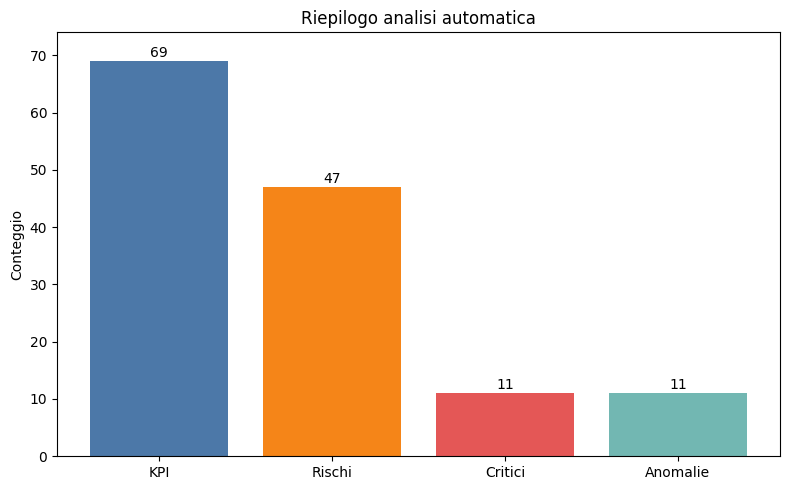

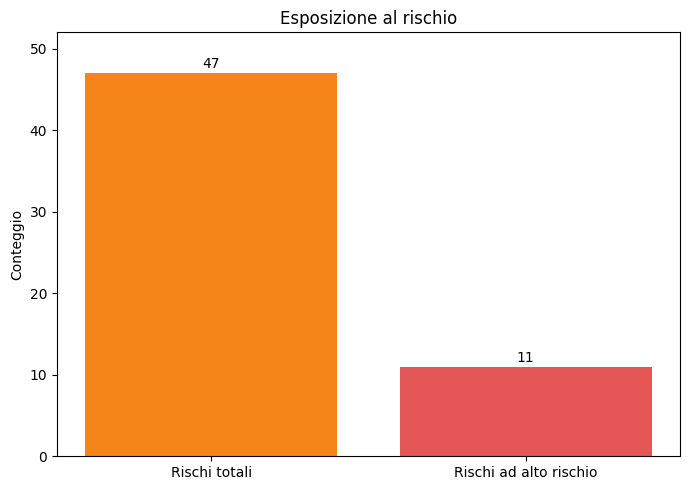

## ⚠️ Attenzione: rilevate 11 anomalie

La documentazione va corretta prima di considerare affidabile l'analisi.

**KPI trovati:** 69  

**Rischi trovati:** 47  

**Rischi critici:** 11  

...

2026-07-09 21:52:52 | INFO | agentic_ai_project | [CHAT_MEMORY] Summary generato: L'utente ha richiesto suggerimenti per scommettere sui mondiali di calcio 2026, ...
INFO:agentic_ai_project:[CHAT_MEMORY] Summary generato: L'utente ha richiesto suggerimenti per scommettere sui mondiali di calcio 2026, ...



> Finished chain.



Invoking: `calcola_margine` with `{'ricavi': 55660000, 'costi': 38710000}`


16950000.0Il margine netto, calcolato sottraendo i costi dai ricavi, è di **16.950.000 €**.


2026-07-09 21:55:22 | INFO | agentic_ai_project | [CHAT_MEMORY] Summary generato: L'utente ha richiesto suggerimenti per scommettere sui mondiali di calcio 2026, ...
INFO:agentic_ai_project:[CHAT_MEMORY] Summary generato: L'utente ha richiesto suggerimenti per scommettere sui mondiali di calcio 2026, ...



> Finished chain.


In [ ]:

display(Markdown("## Grafico riepilogativo"))
plot_summary_counts(analisi_automatica)
plot_risk_summary(analisi_automatica)
show_dashboard(analisi_automatica, scenario_result)
chat_with_agent(agent_with_history, session_id)

# CONCLUSIONI di testing e validazione
1 - l'agente in generale risponde bene e filtra le richieste fuori la sua area di competenza  
2 - richiama i tool quando necessario (è quasi sempre necessario rendere la chiamata un po' esplicita)  
3 - il preprocessing fatica durante le estrazioni di KPI, rischi e rilevazioni anomalie: essendo un campo complicato quello economico sarebbe ideale creare dei files standard da cui l'agente può attingere e recuperare i kpi in modo più puntuale con codice python rispetto a una ricerca eseguita tramite LLM, ma senza conoscere la struttura dei dati in ingresso è impossibile prendere una decisione, per questo sono stati ipotizzati dei documenti generici  
3a - Per la rilevazione anomalie c'è ancora margine di migliormaneto, ma questo è il miglior trade-off trovato in quanto se rimango troppo rigido da un lato rischio di perdere la rilevazioni di anomalie perché il modlelo non trova abbastanza sicurezza nei dati; se resto più permissivo nella ricerca mi riempio ancora di più di doppioni o falsi positivi (cosa che comunque già accade)  
4 - l'agente richiama bene anche i dati che gli sono stati passati con json.dump, ho controllato personalmente la risposta sui kpi e i valori di costi e redditività sono conformi a quanto si trova nel file bilancio_consolidato_FY2025.txt